# Plotting

## Imports and utils

In [1]:
import numpy as np
import math
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


In [2]:
from constants import LRS, BATCH_SIZES, DATA_SCALES, PARAM_SCALES
from utils import Collector

In [3]:
sns.set_style(style="whitegrid")

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
## latex rendering
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})

lr_law_palette = "rocket"
gbs_law_palette = "mako"

param_palettes = {
  '20M': '#2166ac',  # blue
  '50M': '#762a83',  # wine/purple
  '150M': '#d73027',  # red
  '300M': '#FFA500',  # orange
}

In [4]:
MAX_DATA_SCALE_FOR_GBS = {
    16: "1.0B",
    32: "3.0B",
}

MIN_DATA_SCALE_FOR_GBS = {
    128: "1.0B",
    256: "3.0B",
}


def _tokens(data_scale):
    return float(data_scale[:-1]) * 1e9


def data_scales_for(gbs):
    """Data scales in DATA_SCALES that were actually run at this batch size."""
    scales = list(DATA_SCALES)

    max_scale = MAX_DATA_SCALE_FOR_GBS.get(gbs)
    if max_scale is not None:
        scales = [s for s in scales if _tokens(s) <= _tokens(max_scale)]

    min_scale = MIN_DATA_SCALE_FOR_GBS.get(gbs)
    if min_scale is not None:
        scales = [s for s in scales if _tokens(s) >= _tokens(min_scale)]

    return scales


def qlog2_fit(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # if len(x) < 3:
    #     raise ValueError("Need at least 3 points for quadratic fit")

    # transform to log2 space
    x_log = np.log2(x)

    # quadratic fit
    coeffs = np.polyfit(x_log, y, 2)
    a, b, c = coeffs

    # smooth curve
    x_fit_log = np.linspace(x_log.min(), x_log.max(), 200)
    y_fit = a * x_fit_log**2 + b * x_fit_log + c
    x_fit = 2 ** x_fit_log
    return x_fit, y_fit

def compute_loss_loglog(N, D, loss, grid_size=50):
    """
    Fits log(loss) = a log(N) + b log(D) + c using least squares (NumPy only).

    Returns:
        x_scatter, y_scatter
        x_fit, y_fit
        z_fit
    """

    N = np.asarray(N)
    D = np.asarray(D)
    loss = np.asarray(loss)

    mask = np.isfinite(N) & np.isfinite(D) & np.isfinite(loss)
    N, D, loss = N[mask], D[mask], loss[mask]

    if len(N) < 3:
        raise ValueError("Need at least 3 points")

    # design matrix: [log N, log D, 1]
    X = np.stack([np.log(N), np.log(D), np.ones_like(N)], axis=1)
    y = np.log(loss)

    # least squares solve
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    a, b, c = coeffs

    # scatter points
    x_scatter = N
    y_scatter = D

    # grid
    n_grid = np.linspace(N.min(), N.max(), grid_size)
    d_grid = np.linspace(D.min(), D.max(), grid_size)

    x_fit, y_fit = np.meshgrid(n_grid, d_grid)

    Xg = np.stack(
        [np.log(x_fit.ravel()), np.log(y_fit.ravel()), np.ones(x_fit.size)],
        axis=1
    )

    log_pred = Xg @ coeffs
    z_fit = np.exp(log_pred).reshape(grid_size, grid_size)
    return x_fit, y_fit, z_fit 

In [5]:
N_MAP = {
    "20M": 20223232,
    "50M": 45869568,
    "150M": 84494848,
    "300M": 220338048,
}


def compute_learning_rate_law_at_gbs(
    arch_id,
    gbss,
    lr_filter=None,
    min_points=3,
    plot=True,
):
    """Fit log2(lr*) = a n + b d + c n d + e b + f over all (N, D, GBS).

    N, D and GBS are centered log2 values. Returns the fitted rows, the
    design matrix, the centered regressors and a predict function.
    """
    co = Collector(arch_id)

    rows = []

    for gbs in gbss:
        for n in PARAM_SCALES:
            for data_scale in data_scales_for(gbs):
                tokens = float(data_scale[:-1]) * 1e9
                sl = co.index(n=n, d=data_scale, gbs=gbs)
                if lr_filter is not None:
                    sl = lr_filter(sl)
                if len(sl["lr"]) < min_points:
                    continue

                lr_fit, loss_fit = qlog2_fit(sl["lr"], sl["val_loss"])
                optimal_lr = lr_fit[np.argmin(loss_fit)]

                rows.append({
                    "n": n,
                    "gbs": gbs,
                    "data_scale": data_scale,
                    "params": N_MAP[n],
                    "tokens": tokens,
                    "lr": optimal_lr,
                })

    # Work entirely in log2 space.
    log_n = np.log2([row["params"] for row in rows])
    log_d = np.log2([row["tokens"] for row in rows])
    log_b = np.log2([row["gbs"] for row in rows])
    log_lr = np.log2([row["lr"] for row in rows])

    # Center before forming the interaction. This greatly improves conditioning.
    mean_log_n = log_n.mean()
    mean_log_d = log_d.mean()
    mean_log_b = log_b.mean()

    n_centered = log_n - mean_log_n
    d_centered = log_d - mean_log_d
    b_centered = log_b - mean_log_b

    X = np.column_stack([
        n_centered,
        d_centered,
        n_centered * d_centered,
        b_centered,
        np.ones(len(rows)),
    ])

    coeffs, residuals, rank, singular_values = np.linalg.lstsq(
        X, log_lr, rcond=None
    )
    a, b, c, d, e = coeffs

    def predict_lr(params, tokens, gbs):
        n_ = np.log2(params) - mean_log_n
        data_ = np.log2(tokens) - mean_log_d
        batch_ = np.log2(gbs) - mean_log_b

        predicted_log_lr = (
            a * n_
            + b * data_
            + c * n_ * data_
            + d * batch_
            + e
        )
        return 2.0 ** predicted_log_lr

    predicted_log_lr = X @ coeffs
    r_squared = 1.0 - np.sum((log_lr - predicted_log_lr) ** 2) / np.sum(
        (log_lr - log_lr.mean()) ** 2
    )

    print("coefficients:", coeffs)
    print("matrix rank:", rank)
    print("condition number:", np.linalg.cond(X))
    print("log2-space R²:", r_squared)

    if plot:
        # Show the single unified law against every observed configuration.
        for gbs in gbss:
            for n in PARAM_SCALES:
                pair_rows = [
                    row for row in rows
                    if row["gbs"] == gbs and row["n"] == n
                ]

                if not pair_rows:
                    continue

                pair_rows.sort(key=lambda row: row["tokens"])

                x_observed = np.asarray([row["tokens"] for row in pair_rows])
                y_observed = np.asarray([row["lr"] for row in pair_rows])

                x_fit = np.geomspace(
                    x_observed.min(),
                    x_observed.max(),
                    200,
                )
                y_fit = predict_lr(N_MAP[n], x_fit, gbs)

                plt.scatter(x_observed, y_observed)
                plt.plot(x_fit, y_fit, label=n)

            visible_scales = data_scales_for(gbs)
            ticks = [float(data_scale[:-1]) * 1e9 for data_scale in visible_scales]

            plt.xscale("log", base=2)
            plt.yscale("log", base=2)
            plt.xticks(ticks, visible_scales)
            plt.xlabel("Token budget")
            plt.ylabel(r"Learning rate $\eta$")
            plt.title(f"Unified learning-rate law, GBS={gbs}")
            plt.legend()
            plt.show()
            plt.close()

    return {
        "rows": rows,
        "coeffs": coeffs,
        "X": X,
        "log_lr": log_lr,
        "n_centered": n_centered,
        "d_centered": d_centered,
        "b_centered": b_centered,
        "r_squared": r_squared,
        "predict_lr": predict_lr,
    }


def statistical_test_for_coefficients(law):
    """Refit the law with OLS to get HC3 errors and FDR-adjusted p-values."""
    X_stats = pd.DataFrame({
        "log2_params": law["n_centered"],
        "log2_tokens": law["d_centered"],
        "params_x_tokens": law["n_centered"] * law["d_centered"],
        "log2_gbs": law["b_centered"],
    })

    # Adds the intercept as a separately named coefficient.
    X_stats = sm.add_constant(X_stats)

    model = sm.OLS(law["log_lr"], X_stats)

    # HC3 gives more reliable standard errors when residual variance is not constant.
    result = model.fit(cov_type="HC3")

    confidence_intervals = result.conf_int(alpha=0.05)
    adjusted_pvalues = multipletests(
        result.pvalues,
        alpha=0.05,
        method="fdr_bh",
    )[1]

    coefficient_tests = pd.DataFrame({
        "coefficient": result.params,
        "std_error": result.bse,
        "t_statistic": result.tvalues,
        "p_value": result.pvalues,
        "adjusted_p_value": adjusted_pvalues,
        "ci_95_lower": confidence_intervals[0],
        "ci_95_upper": confidence_intervals[1],
    })

    coefficient_tests["significant"] = (
        coefficient_tests["adjusted_p_value"] < 0.05
    )

    print(result.summary())
    print("\nCoefficient significance tests:")
    print(coefficient_tests.to_string(float_format=lambda value: f"{value:.6g}"))

    return result, coefficient_tests


## Pure Attention $\rho=0$

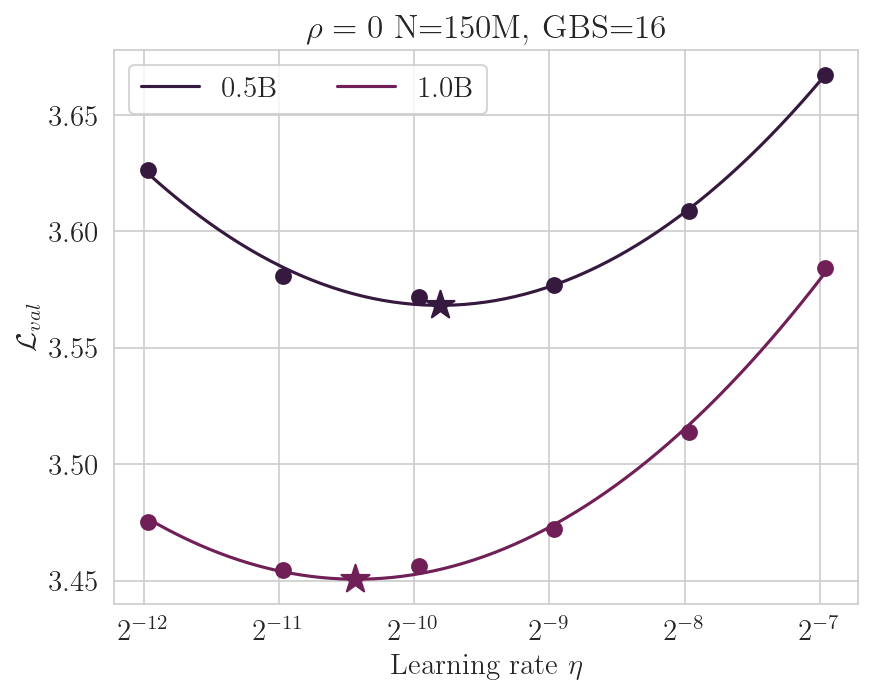

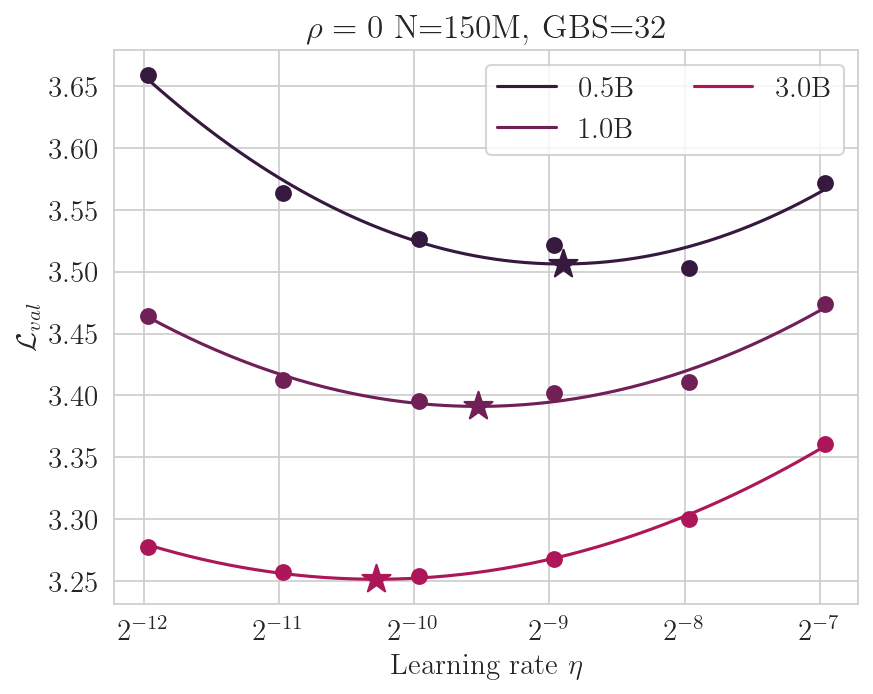

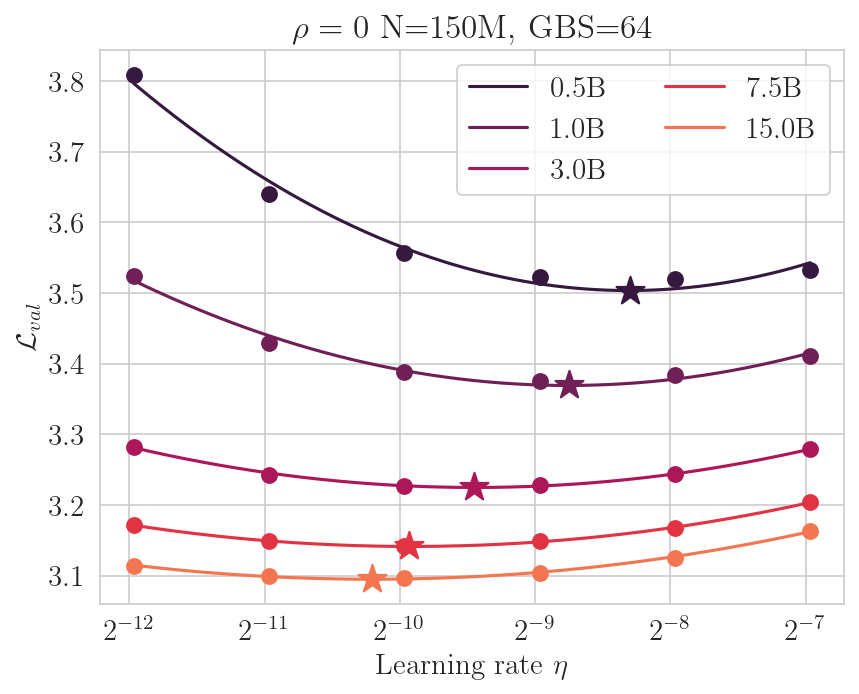

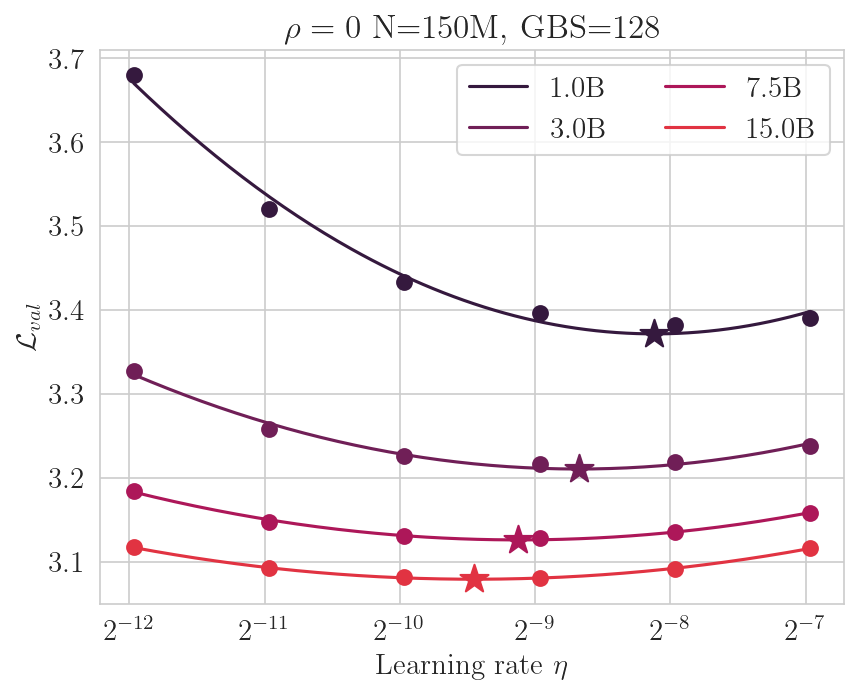

<Figure size 960x720 with 0 Axes>

In [6]:
def in_lr_grid(df):
    """Drop rows from superseded attn sweeps that used a different lr grid."""
    return df[df["lr"].isin(LRS)]


co = Collector("attn")
ns=["150M"]
gbss=[16, 32, 64, 128]

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = in_lr_grid(co.index(n=n, d=d, gbs=gbs))
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")
            if n == '300M' and d == '15.0B':
                print(n, gbs, d, xf_min)

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=0$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()


coefficients: [-0.28567565 -0.35011773 -0.04373272  0.69237766 -9.11025665]
matrix rank: 5
condition number: 2.475062026110859
log2-space R²: 0.9644989805420685


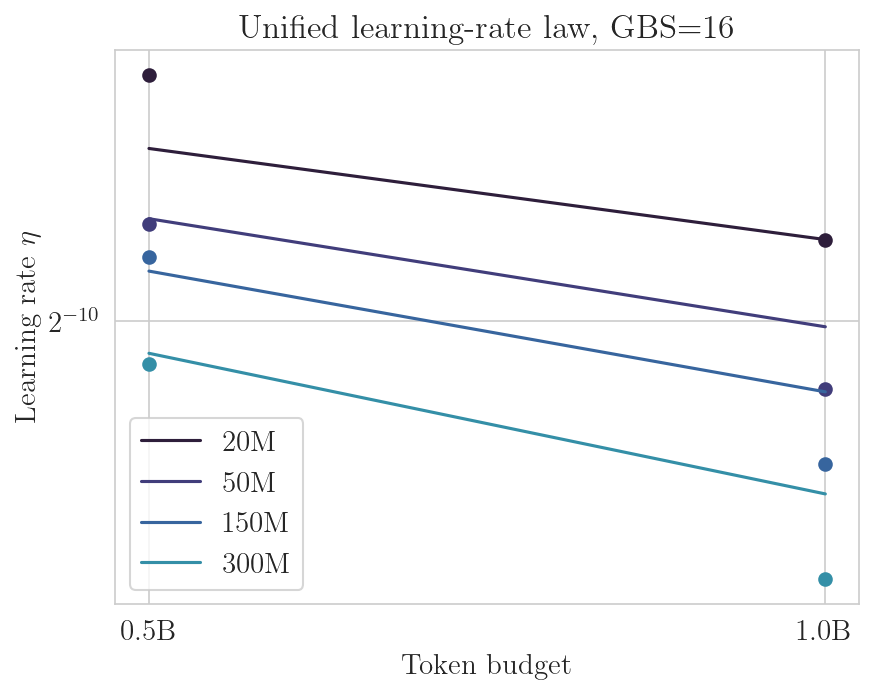

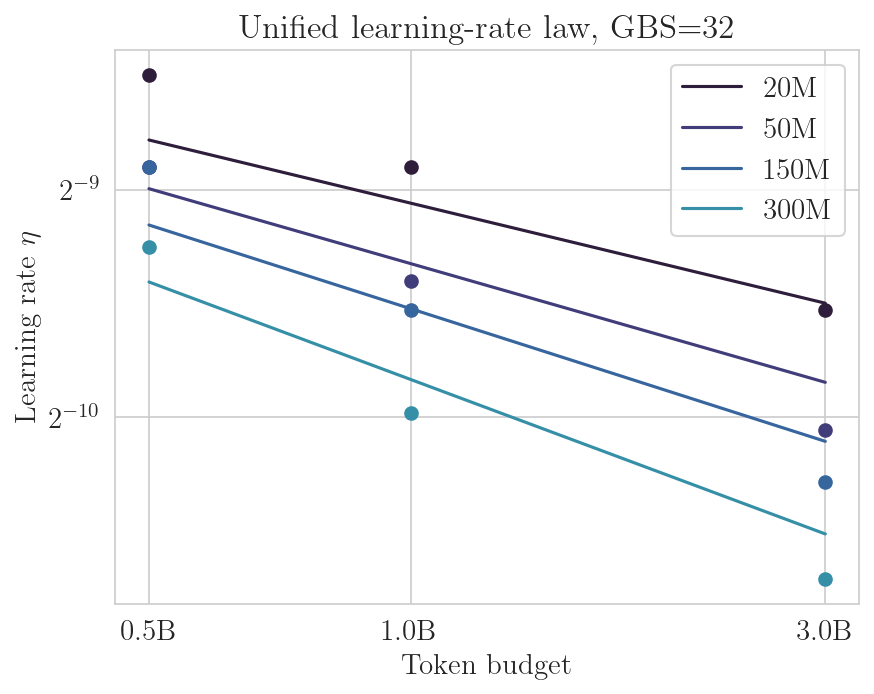

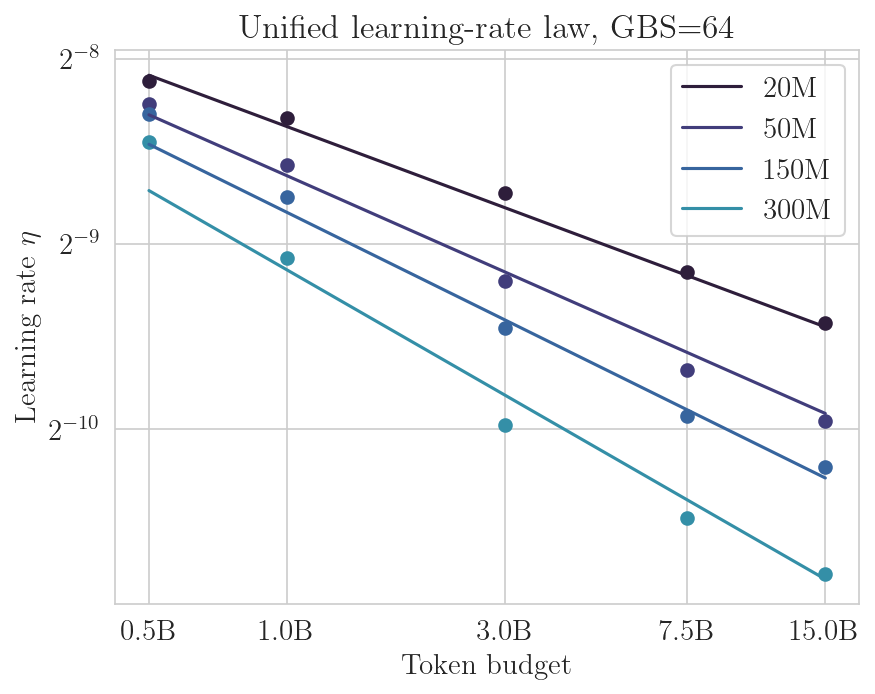

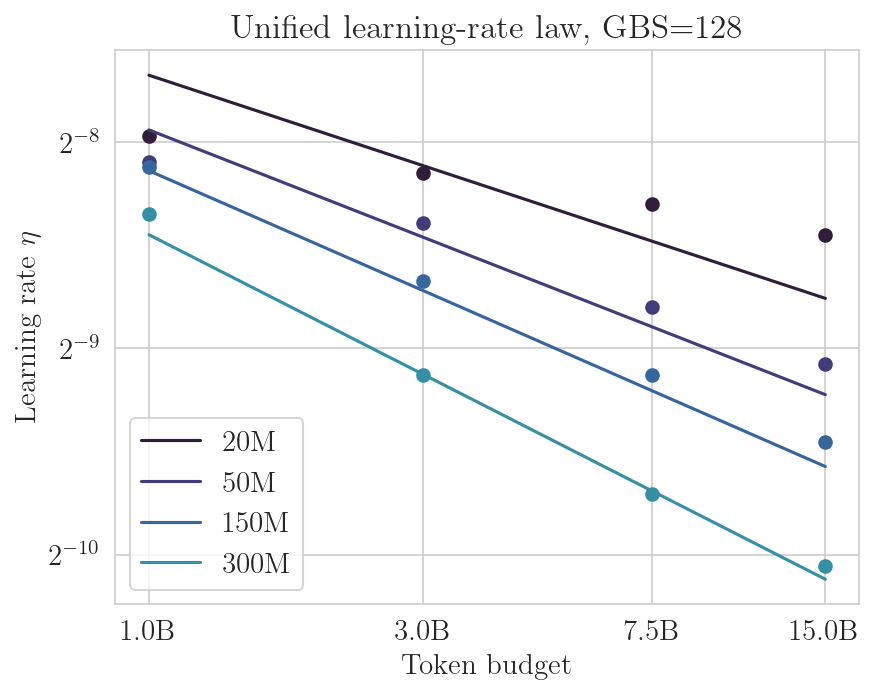

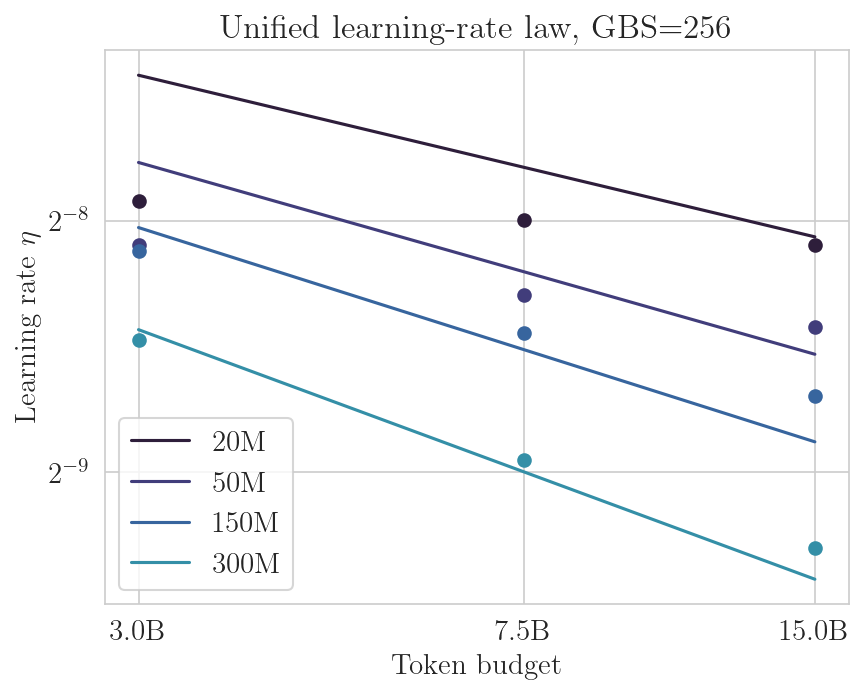

In [7]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "attn",
    gbss=[16, 32, 64, 128, 256],
    lr_filter=in_lr_grid,
)


In [8]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     229.1
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           8.83e-37
Time:                        11:49:45   Log-Likelihood:                 32.437
No. Observations:                  68   AIC:                            -54.87
Df Residuals:                      63   BIC:                            -43.78
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.1103      0.020   -4

## Pure GDN $\rho=1$

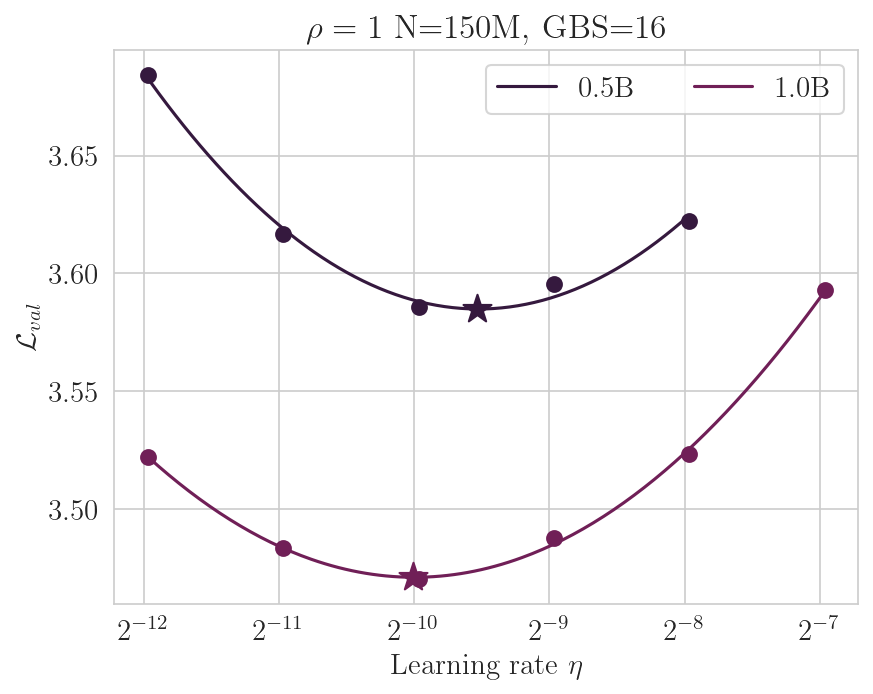

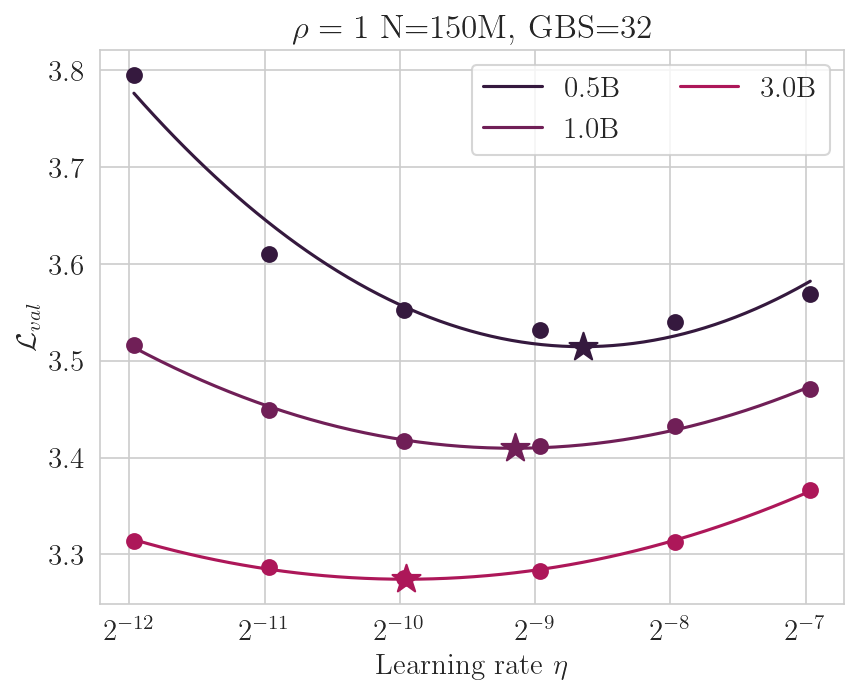

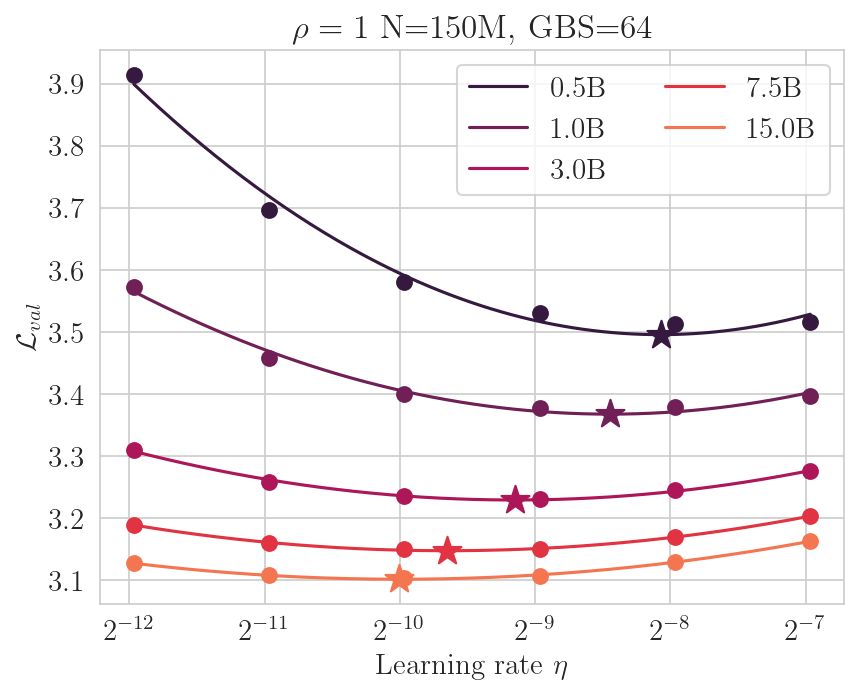

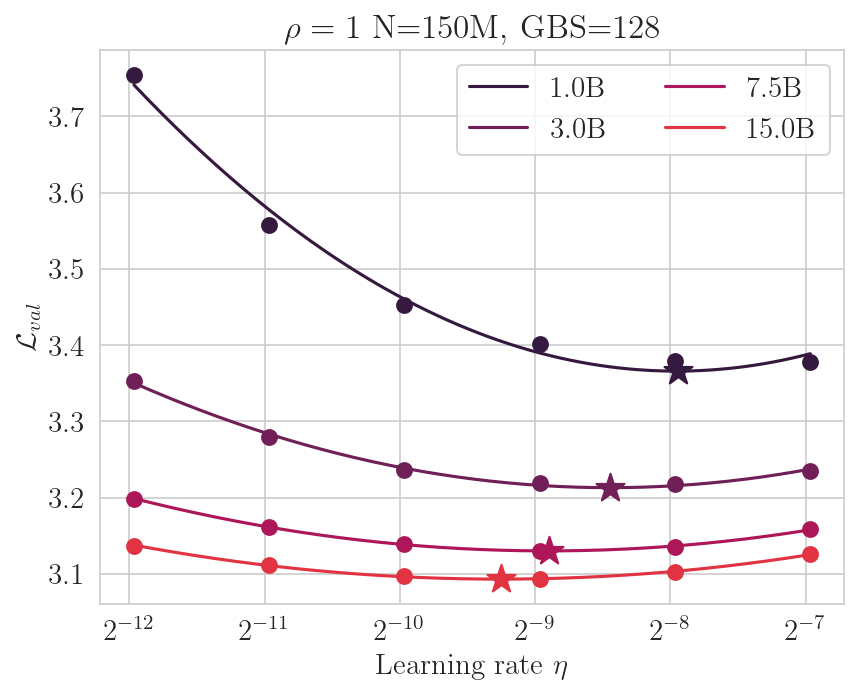

<Figure size 960x720 with 0 Axes>

In [9]:
ns=["150M"]
gbss=[16, 32, 64, 128]
co = Collector("gdn")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")
            if n == '300M' and d == '15.0B':
                print(n, gbs, d, xf_min)

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()


coefficients: [-0.27773274 -0.32268565 -0.04983794  0.60609211 -8.90502486]
matrix rank: 5
condition number: 2.637670397793383
log2-space R²: 0.9364726054114911


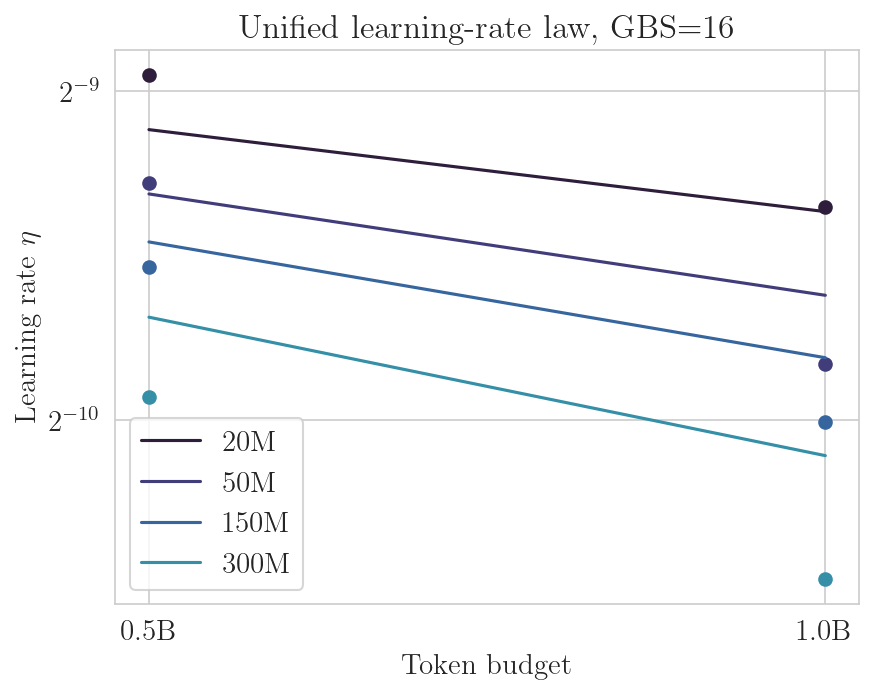

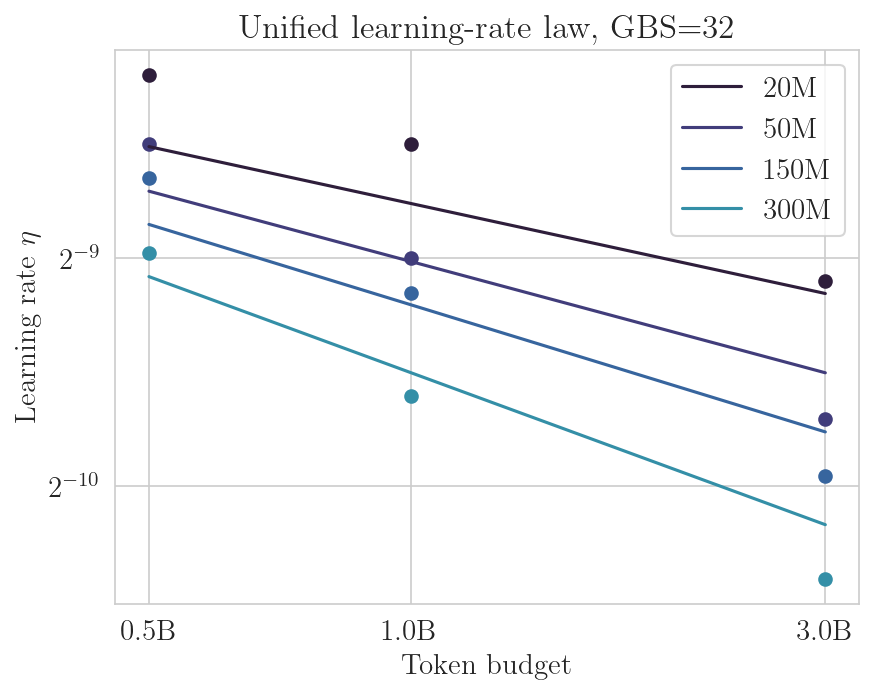

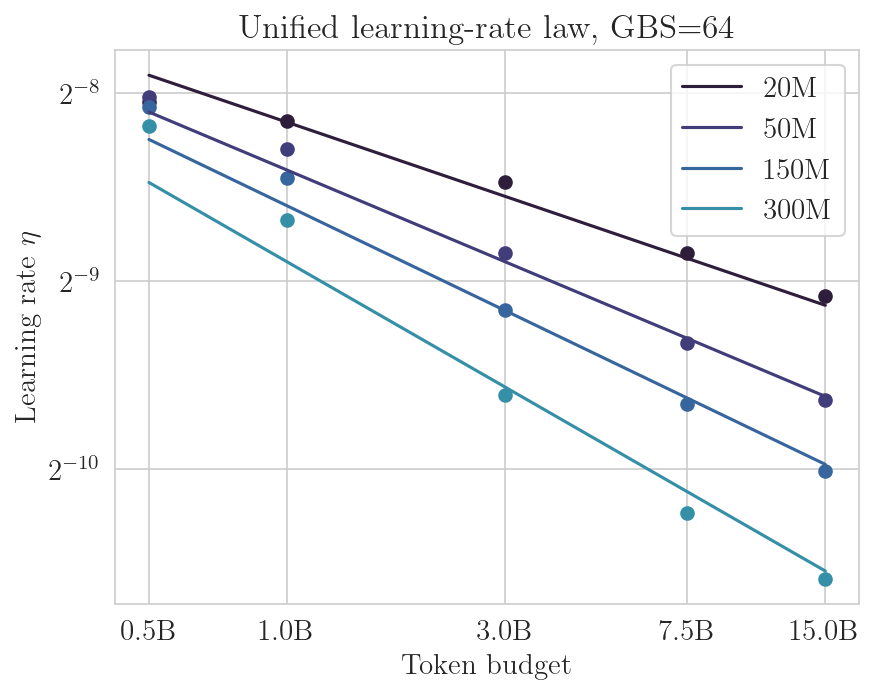

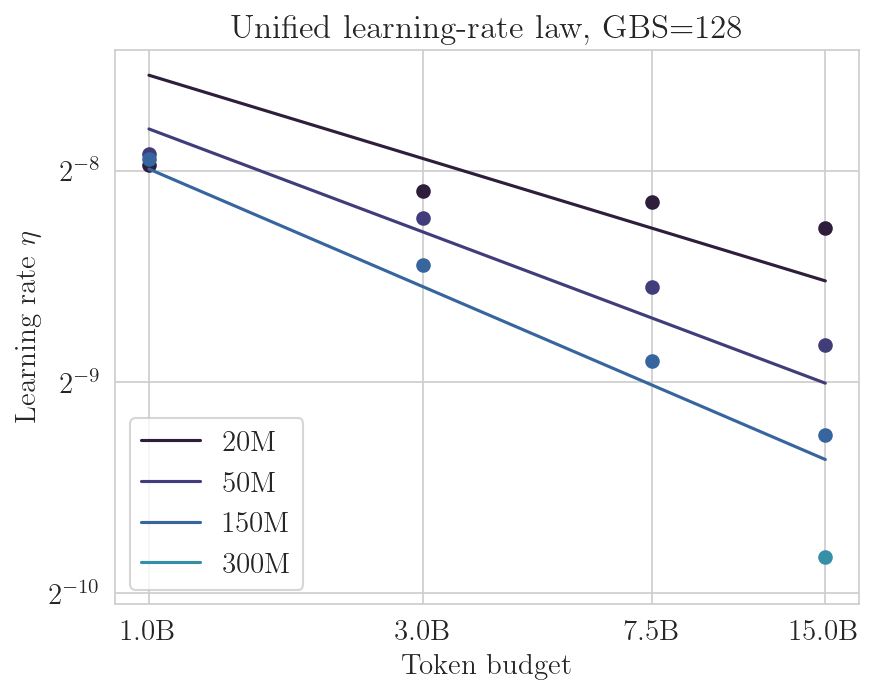

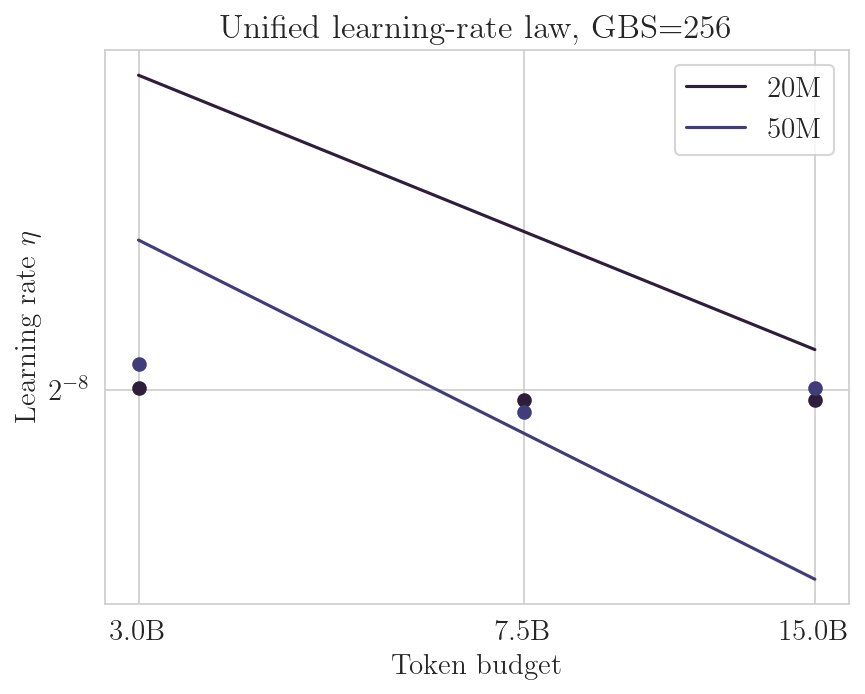

In [10]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "gdn",
    gbss=[16, 32, 64, 128, 256],
)


In [11]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     119.8
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           3.57e-26
Time:                        11:49:45   Log-Likelihood:                 13.270
No. Observations:                  59   AIC:                            -16.54
Df Residuals:                      54   BIC:                            -6.152
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.9050      0.028   -3

## 1:1 GDN:ATTN $\rho=0.5$

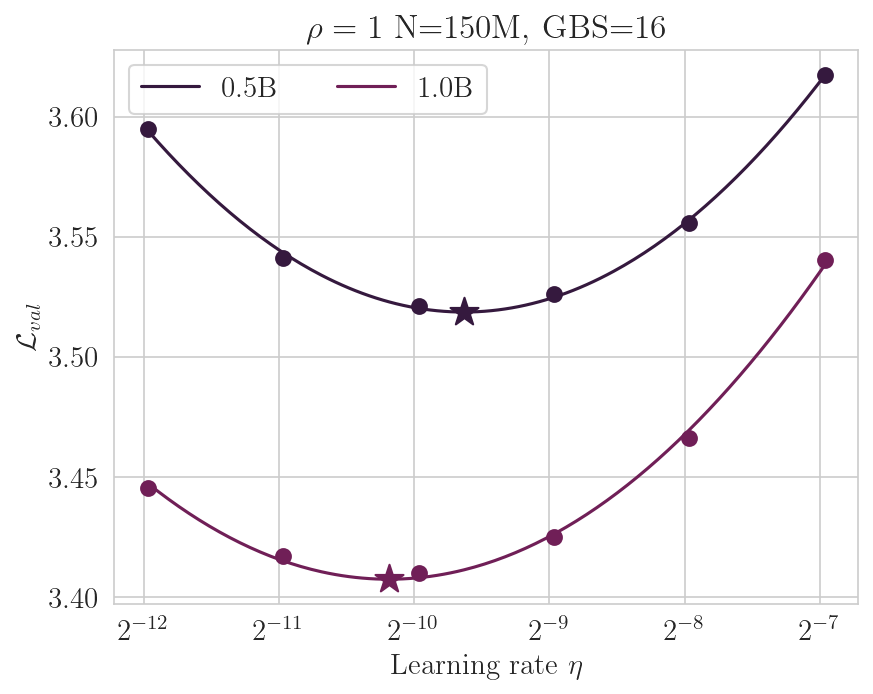

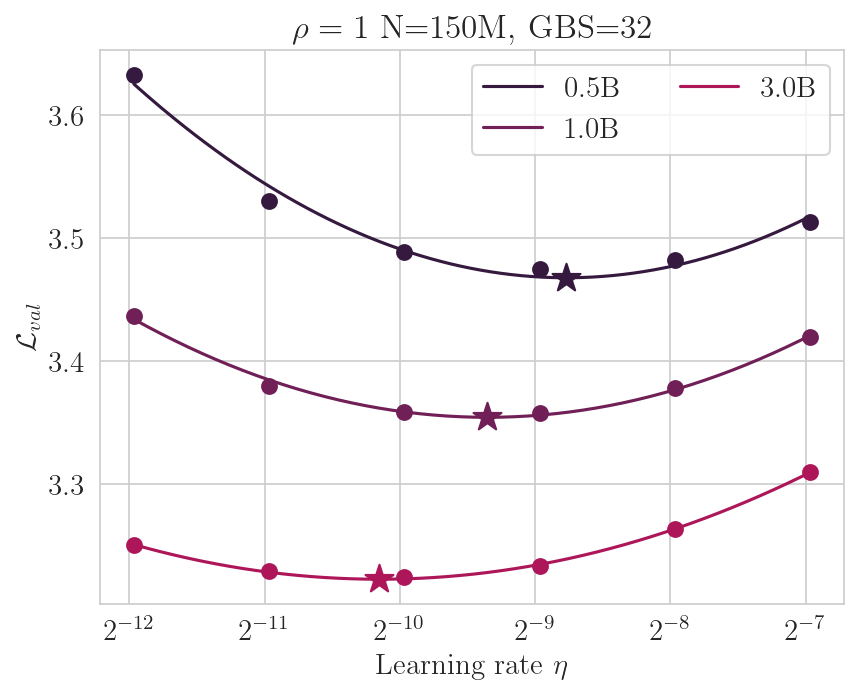

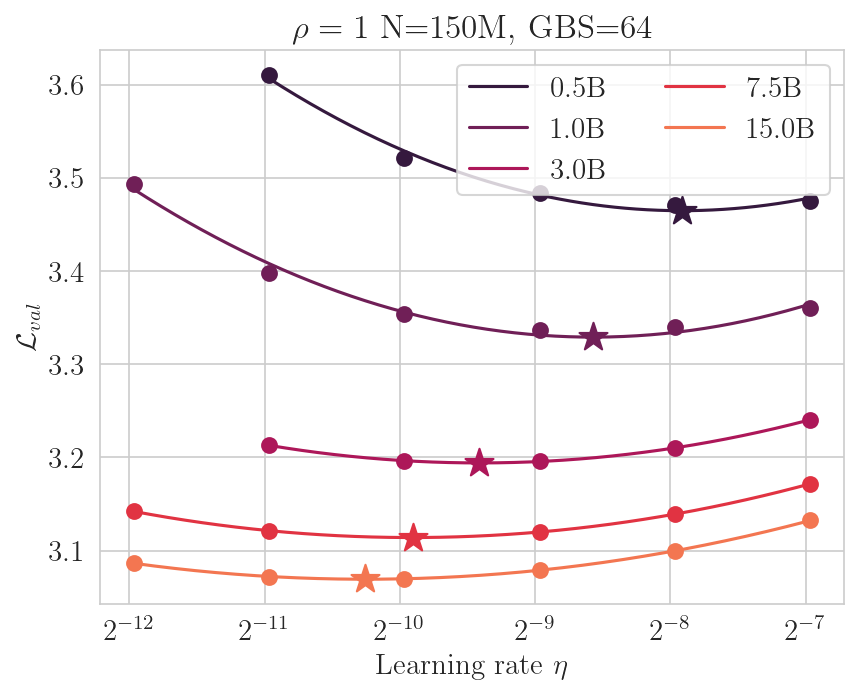

<Figure size 960x720 with 0 Axes>

In [12]:
ns=["150M"]
gbss=[16, 32, 64]
co = Collector("gdn+attn_1-1")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()

coefficients: [-0.25532003 -0.40205327 -0.04432008  0.69406483 -9.15313508]
matrix rank: 5
condition number: 2.7459485078013635
log2-space R²: 0.966962874225181


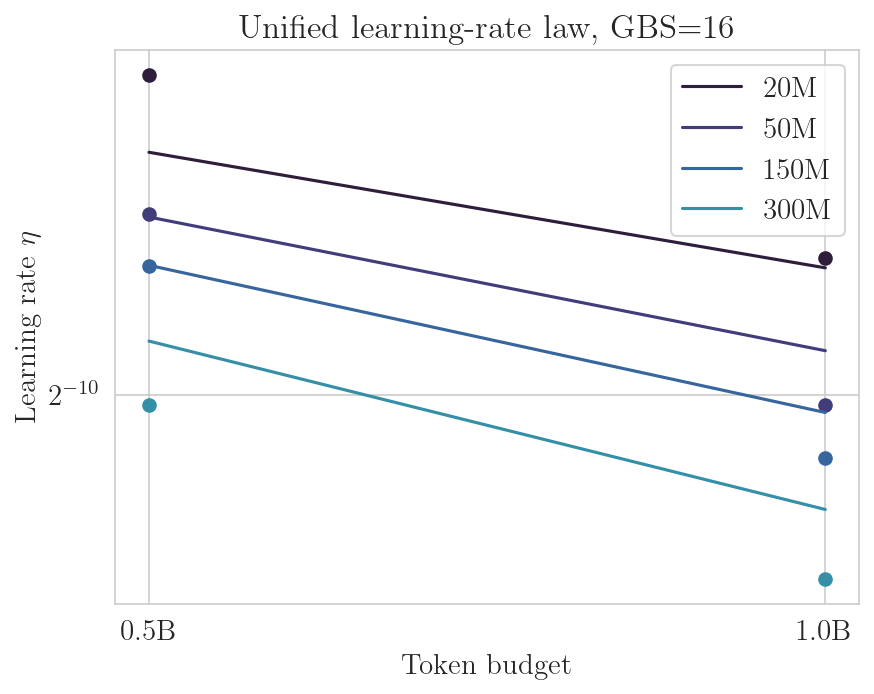

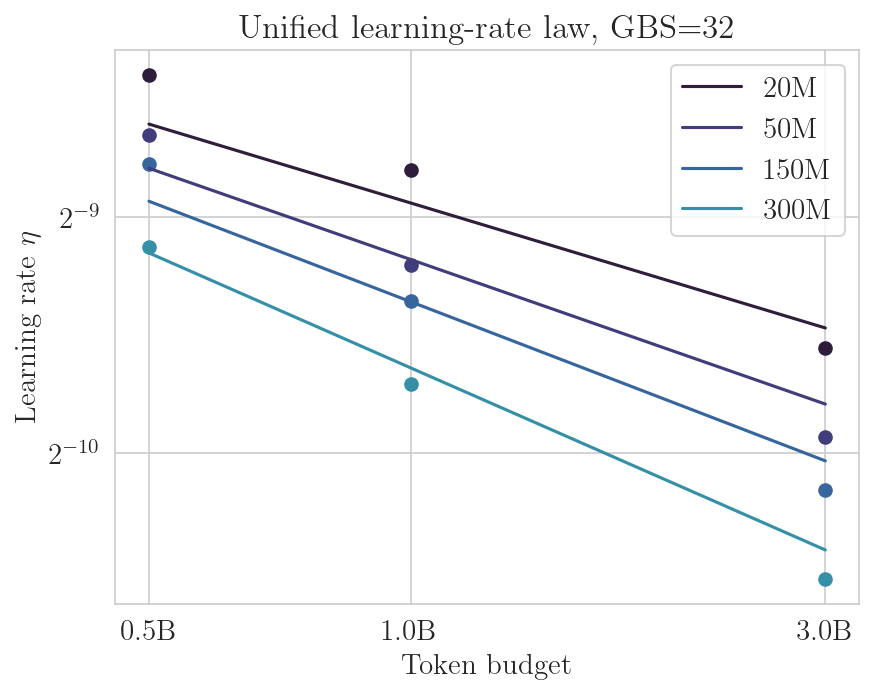

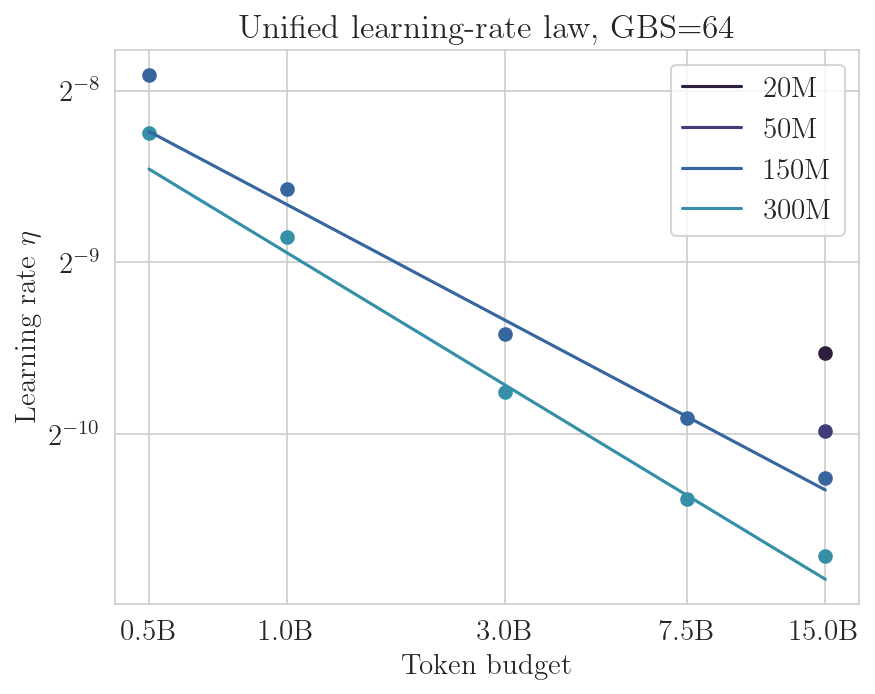

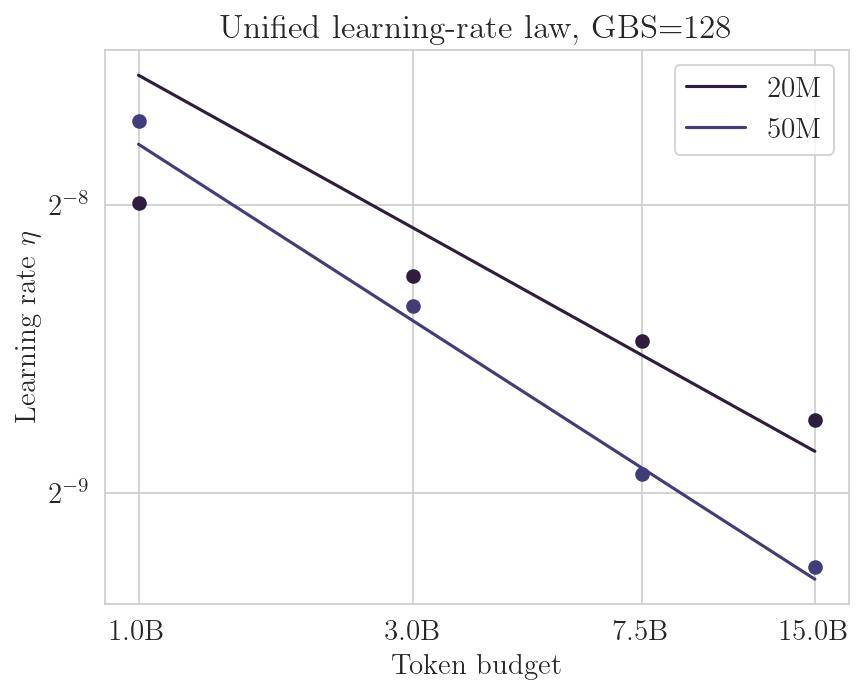

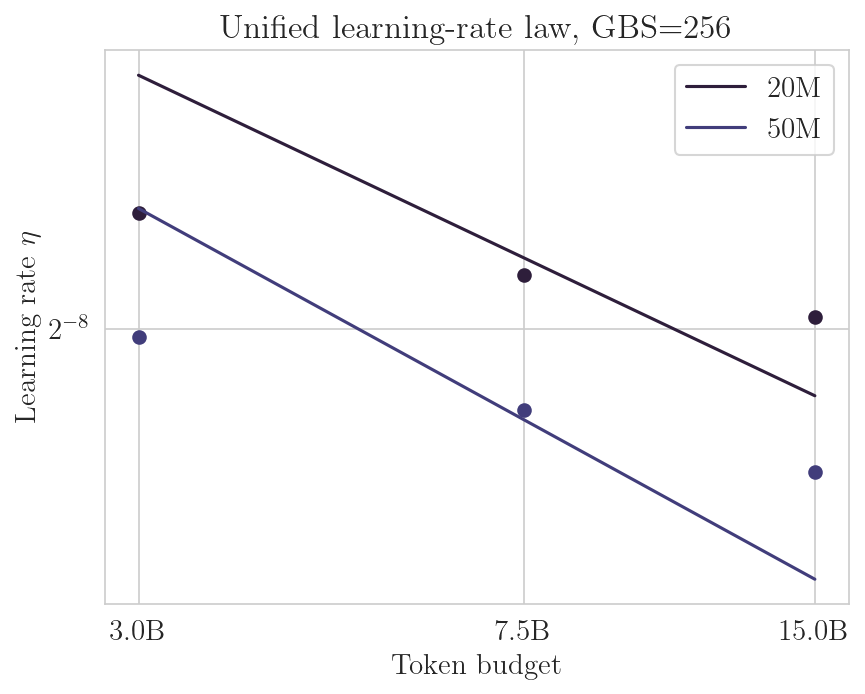

In [13]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "gdn+attn_1-1",
    gbss=[16, 32, 64, 128, 256],
)


In [14]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     162.4
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           1.46e-24
Time:                        11:49:46   Log-Likelihood:                 20.514
No. Observations:                  46   AIC:                            -31.03
Df Residuals:                      41   BIC:                            -21.89
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.1531      0.029   -3

# 3:1 GDN:ATTN ($\rho=0.75$)

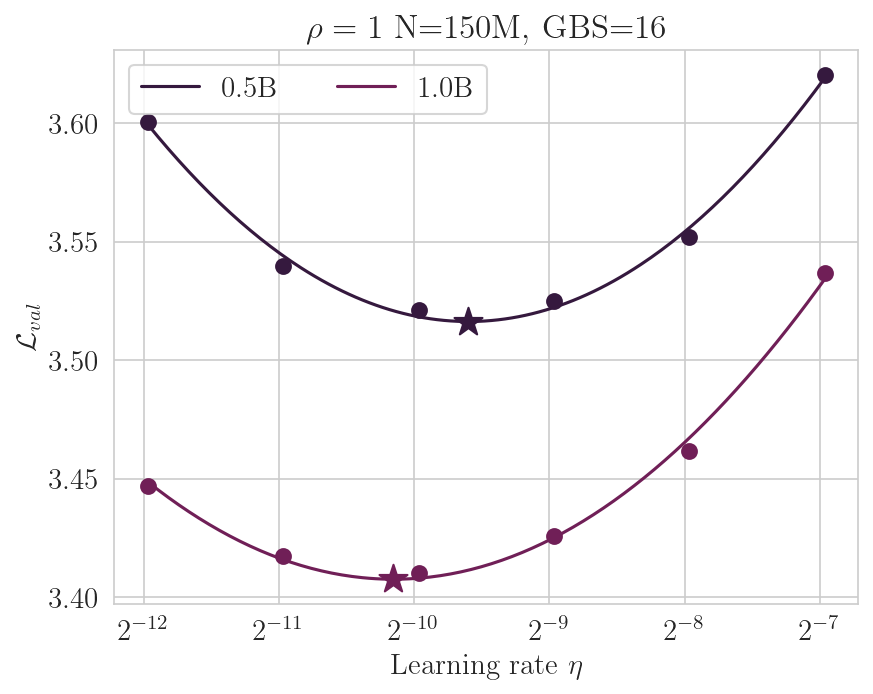

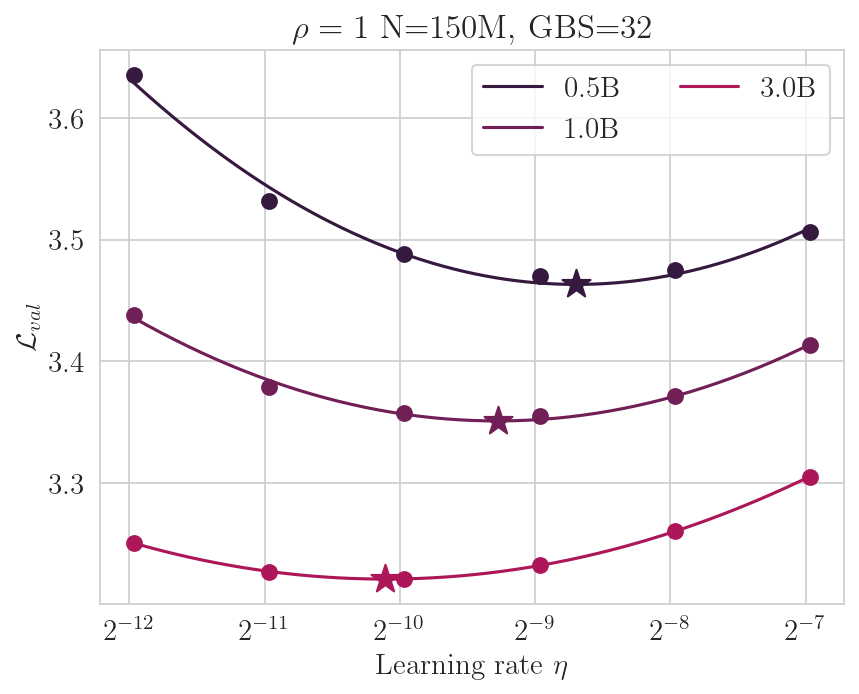

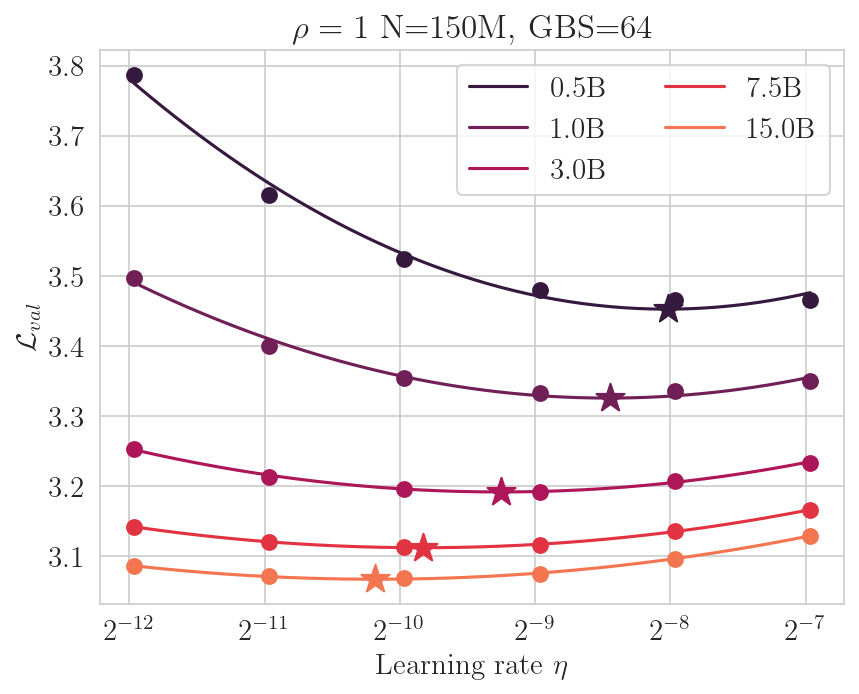

/var/folders/76/k9dkfmf92q19jtdmr7qd_nh00000gn/T/ipykernel_62514/1640562776.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncols=2)


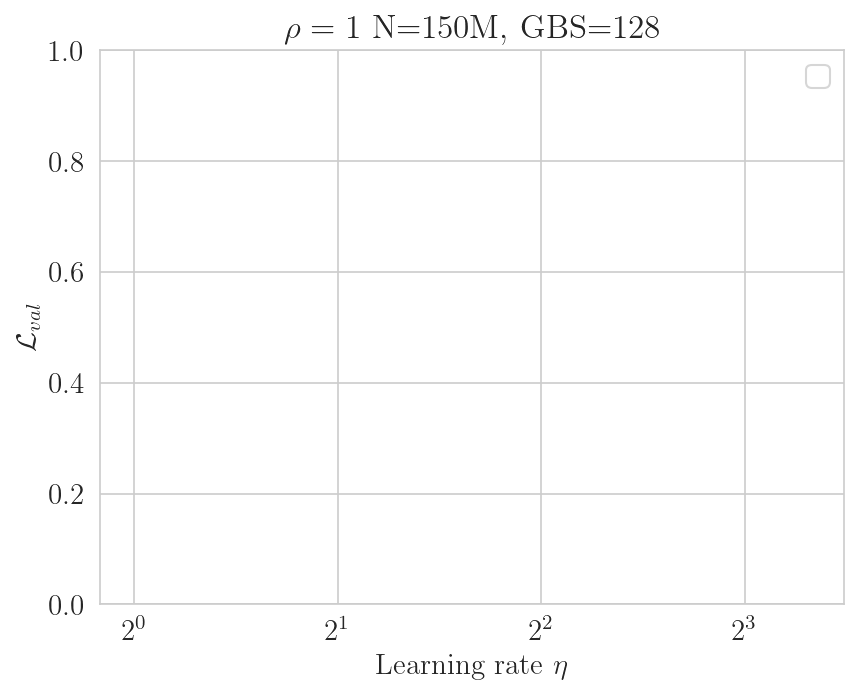

<Figure size 960x720 with 0 Axes>

In [15]:
ns=["150M"]
gbss=[16, 32, 64, 128]
co = Collector("gdn+attn_3-1")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()

coefficients: [-0.26808365 -0.37225755 -0.04259433  0.65532536 -9.05678478]
matrix rank: 5
condition number: 2.523776460635662
log2-space R²: 0.9493891628692169


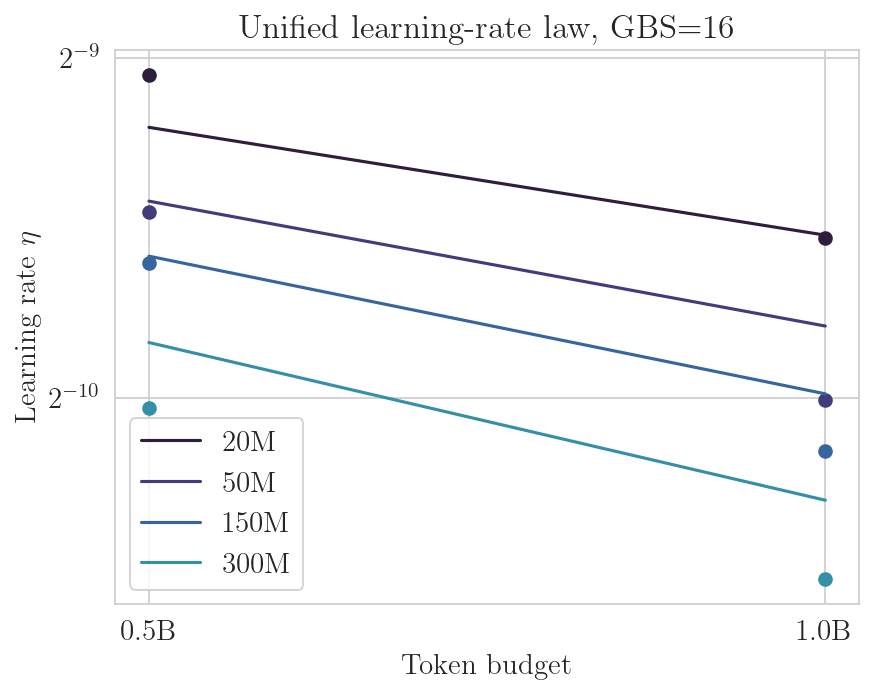

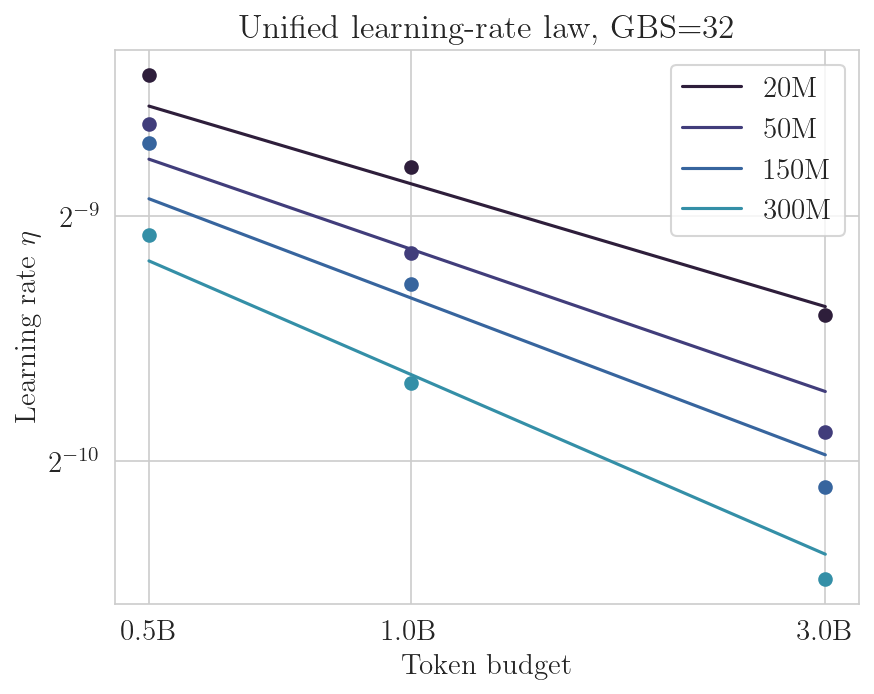

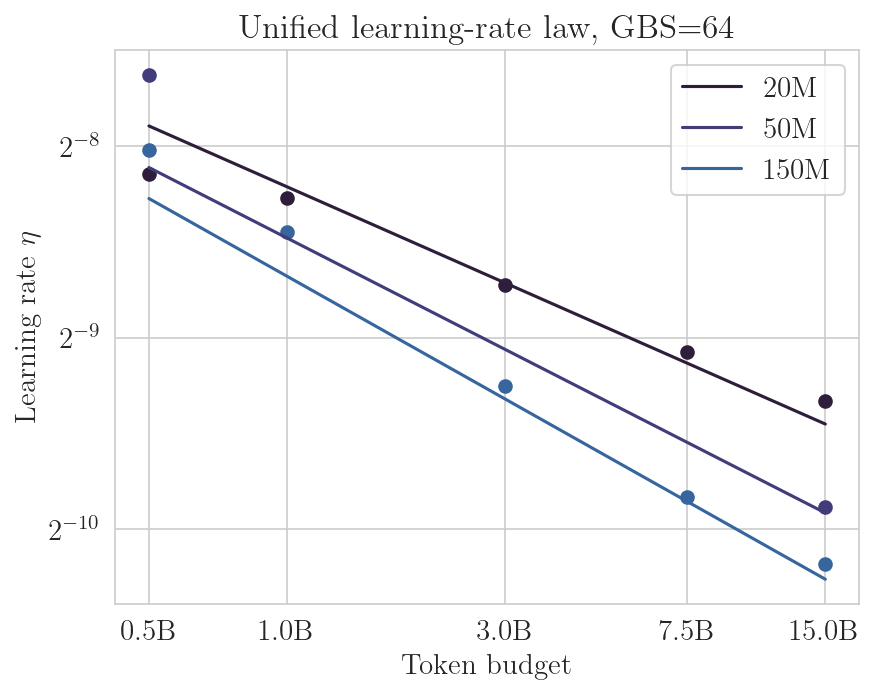

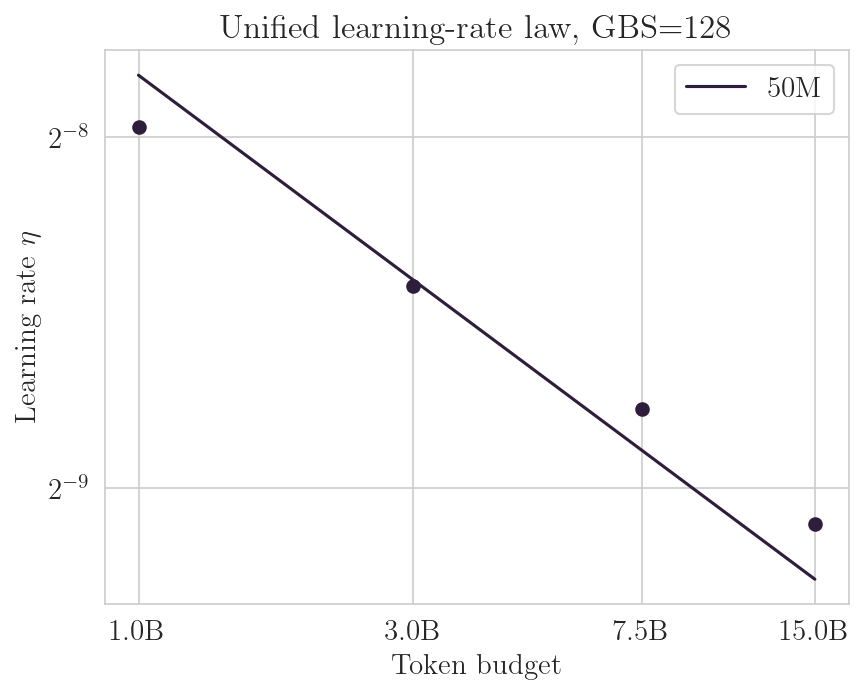

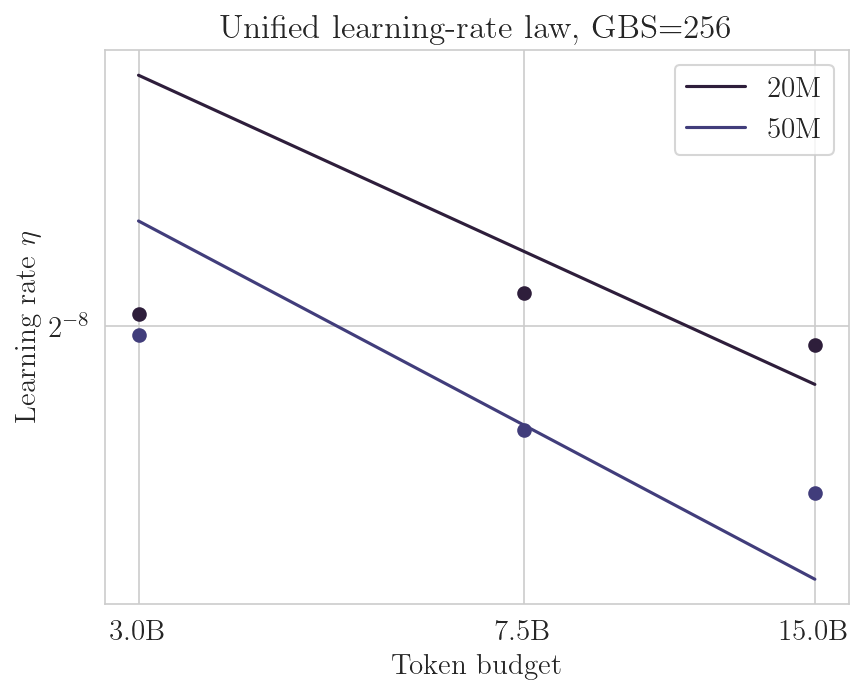

In [16]:
sns.set_palette(sns.color_palette("mako"))

law = compute_learning_rate_law_at_gbs(
    "gdn+attn_3-1",
    gbss=[16, 32, 64, 128, 256],
)


In [17]:
result, coefficient_tests = statistical_test_for_coefficients(law)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     78.27
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           1.55e-17
Time:                        11:49:46   Log-Likelihood:                 13.070
No. Observations:                  42   AIC:                            -16.14
Df Residuals:                      37   BIC:                            -7.451
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.0568      0.031   -2

# (un-decayed) 1:3 GDN:ATTN ($\rho=0.25$)

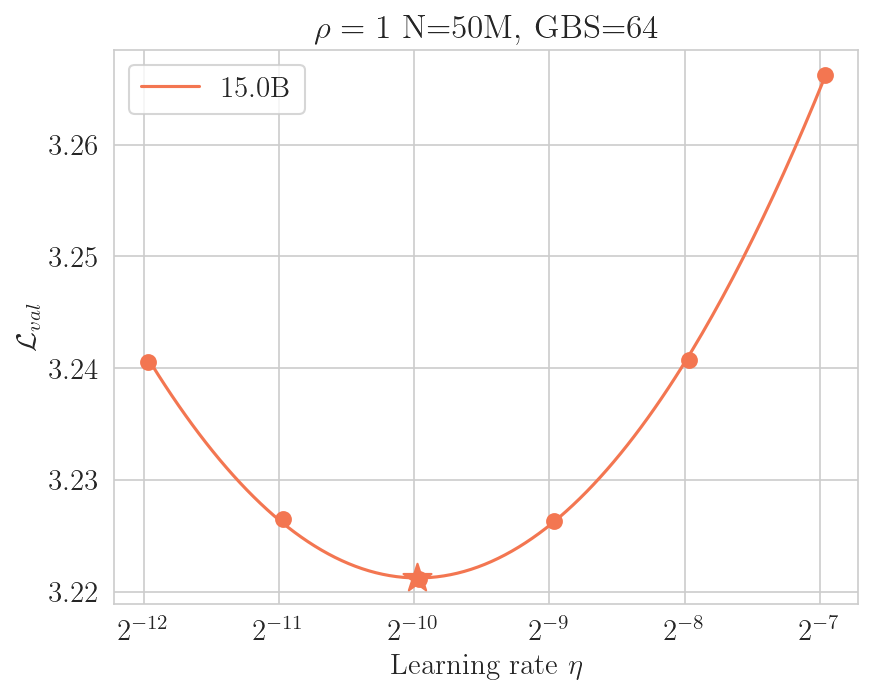

<Figure size 960x720 with 0 Axes>

In [18]:
ns=["50M"]
gbss=[64]
co = Collector("gdn+attn_1-3")

sns.set_palette(sns.color_palette("rocket"))

for n in ns:
    for gbs in gbss:
        for i, d in enumerate(data_scales_for(gbs)):
            slc = co.index(n=n, d=d, gbs=gbs)
            if len(slc["lr"]) < 3:
                continue
            xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
            yf_min = yf.min()
            xf_min = xf[yf.argmin()]
            
            plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
            plt.plot(xf, yf, label=d, c=f"C{i}")
            plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

        plt.xlabel(r"Learning rate $\eta$")
        plt.ylabel(r"$\mathcal{L}_{val}$")
        plt.xscale("log", base=2)
        plt.title(r"$\rho=1$ " + f"N={n}, GBS={gbs}")
        plt.legend(ncols=2)
        plt.show()
        plt.cla()
        plt.clf()

---
---

# Learning-rate transferability from Pure Attention

**What this section measures.** For every architecture $X \neq$ Pure Attention and every
cell $(N, D, \mathrm{GBS})$, take the loss-versus-lr quadratic already fitted for $X$ and
evaluate it at *Pure Attention's* optimal learning rate for the same cell. The gap

$$\Delta = \mathcal{L}_X(\eta^*_{\rho=0}) - \mathcal{L}_X(\eta^*_X)$$

is the loss cost of skipping the lr sweep for $X$ and reusing the Pure Attention value.
No new runs are needed: both numbers come from the same fitted curve.

**Reference scale.** $\Delta$ in nats is not interpretable alone, so each cell also carries
`grid_step_cost`: the loss cost, on that same curve, of being one lr grid step ($2\times$)
away from $X$'s own optimum. If $\Delta$ sits well below this, reusing the Pure Attention
learning rate is cheaper than the resolution of the sweep itself.

**Where to look**

| | Figure | Reads |
|---|---|---|
| Plot 1 | Transfer penalty per architecture | Headline: how large $\Delta$ is against the $2\times$-lr-error band |
| Plot 2 | $\eta^*_X$ against $\eta^*_{\rho=0}$ | Mechanism: how closely the optima coincide, and whether the offset is systematic |
| Plot 3 | $\Delta$ against compute $6ND$ | Whether transferability holds as scale grows |
| Plot 4 | One cell, both curves | Illustration of what $\Delta$ is |

$\rho=0.25$ (1:3) is excluded: those runs are not finished.


## Transfer table

In [19]:
import numpy as np
import pandas as pd

TRANSFER_ARCH_IDS = ["gdn", "gdn+attn_1-1", "gdn+attn_3-1"]

ARCH_LABELS = {
    "attn": r"$\rho=0$ (attn)",
    "gdn": r"$\rho=1$ (gdn)",
    "gdn+attn_1-1": r"$\rho=0.5$ (1:1)",
    "gdn+attn_3-1": r"$\rho=0.75$ (3:1)",
}


def quad_coeffs_log2(lrs, losses):
    """Quadratic fit of loss against log2(lr). Returns coeffs or None."""
    lrs = np.asarray(lrs, dtype=float)
    losses = np.asarray(losses, dtype=float)

    mask = np.isfinite(lrs) & np.isfinite(losses)
    lrs, losses = lrs[mask], losses[mask]

    if len(lrs) < 3:
        return None

    return np.polyfit(np.log2(lrs), losses, 2)


def quad_eval(coeffs, lr):
    a, b, c = coeffs
    x = np.log2(lr)
    return a * x**2 + b * x + c


def quad_min_log2(coeffs):
    """Vertex of the quadratic in log2(lr) space. Returns None if not a minimum."""
    a, b, _ = coeffs
    if a <= 0:
        return None
    return -b / (2.0 * a)


def cell_fit(collector, n, d, gbs, lr_filter=None):
    """Fit one (N, D, GBS) cell. Returns coeffs, log2 lr grid range, or None."""
    sl = collector.index(n=n, d=d, gbs=gbs)
    if lr_filter is not None:
        sl = lr_filter(sl)

    grouped = sl.groupby("lr")["val_loss"].mean().reset_index().dropna()
    coeffs = quad_coeffs_log2(grouped["lr"], grouped["val_loss"])
    if coeffs is None:
        return None

    log2_lrs = np.log2(grouped["lr"].values)
    return coeffs, log2_lrs.min(), log2_lrs.max()


def build_transfer_table(
    collectors,
    gbss,
    param_scales,
    data_scales_for,
    n_map,
    arch_ids=None,
    attn_lr_filter=None,
):
    """One row per comparable (arch, N, D, GBS) cell.

    For each cell the attention optimum is read off the attention fit at the
    same (N, D, GBS) and pushed through the architecture's own fitted curve.
    """
    if arch_ids is None:
        arch_ids = TRANSFER_ARCH_IDS

    rows = []

    for gbs in gbss:
        for n in param_scales:
            for d in data_scales_for(gbs):
                attn_fit = cell_fit(
                    collectors["attn"], n, d, gbs, lr_filter=attn_lr_filter
                )
                if attn_fit is None:
                    continue

                attn_coeffs, _, _ = attn_fit
                attn_vertex = quad_min_log2(attn_coeffs)
                if attn_vertex is None:
                    continue

                for arch_id in arch_ids:
                    fit = cell_fit(collectors[arch_id], n, d, gbs)
                    if fit is None:
                        continue

                    coeffs, log2_lr_lo, log2_lr_hi = fit
                    vertex = quad_min_log2(coeffs)
                    if vertex is None:
                        continue

                    loss_own = quad_eval(coeffs, 2.0**vertex)
                    loss_at_attn = quad_eval(coeffs, 2.0**attn_vertex)

                    # Cost of a single lr grid step (2x) away from the optimum,
                    # used as the reference scale for the transfer penalty.
                    grid_step_cost = 0.5 * (
                        quad_eval(coeffs, 2.0 ** (vertex + 1.0))
                        + quad_eval(coeffs, 2.0 ** (vertex - 1.0))
                    ) - loss_own

                    rows.append({
                        "arch_id": arch_id,
                        "n": n,
                        "d": d,
                        "gbs": gbs,
                        "params": n_map[n],
                        "tokens": float(d[:-1]) * 1e9,
                        "compute": 6.0 * n_map[n] * float(d[:-1]) * 1e9,
                        "lr_star": 2.0**vertex,
                        "lr_star_attn": 2.0**attn_vertex,
                        "log2_ratio": attn_vertex - vertex,
                        "loss_star": loss_own,
                        "loss_at_attn_lr": loss_at_attn,
                        "delta": loss_at_attn - loss_own,
                        "grid_step_cost": grid_step_cost,
                        "extrapolated": bool(
                            attn_vertex < log2_lr_lo or attn_vertex > log2_lr_hi
                        ),
                    })

    return pd.DataFrame(rows)


def transfer_summary(table):
    """Per-architecture summary of the transfer penalty."""
    band = table["grid_step_cost"].median()

    out = []
    for arch_id, group in table.groupby("arch_id"):
        out.append({
            "arch_id": arch_id,
            "cells": len(group),
            "median_delta": group["delta"].median(),
            "p90_delta": group["delta"].quantile(0.9),
            "max_delta": group["delta"].max(),
            "median_abs_log2_ratio": group["log2_ratio"].abs().median(),
            "frac_below_grid_step": (
                group["delta"] < group["grid_step_cost"]
            ).mean(),
            "extrapolated": int(group["extrapolated"].sum()),
        })

    summary = pd.DataFrame(out)
    summary.attrs["median_grid_step_cost"] = band
    return summary

In [20]:
def plot_transfer_penalty(table, ax=None):
    """Plot 1: distribution of the transfer penalty per architecture."""

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    order = [a for a in TRANSFER_ARCH_IDS if a in set(table["arch_id"])]
    band = table["grid_step_cost"].median()

    ax.axhline(band, color="0.35", ls="--", lw=1.2, zorder=1)
    ax.text(
        len(order) - 0.45,
        band * 1.1,
        r"median cost of a $2\times$ lr error",
        ha="right",
        va="bottom",
        fontsize=11,
        color="0.3",
    )

    sns.stripplot(
        data=table, x="arch_id", y="delta", order=order,
        hue="arch_id", hue_order=order, palette="rocket",
        size=6, alpha=0.7, jitter=0.25, legend=False, ax=ax, zorder=2,
    )
    sns.boxplot(
        data=table, x="arch_id", y="delta", order=order,
        showfliers=False, showbox=False, showcaps=False,
        whiskerprops={"visible": False},
        medianprops={"color": "k", "lw": 2},
        ax=ax, zorder=3,
    )

    ax.set_yscale("log")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([ARCH_LABELS[a] for a in order])
    ax.set_xlabel("Architecture")
    ax.set_ylabel(r"$\Delta = \mathcal{L}_X(\eta^*_{\rho=0}) - \mathcal{L}_X(\eta^*_X)$")
    ax.set_title("Cost of borrowing the Pure Attention learning rate")
    return ax


def plot_optimum_agreement(table, ax=None):
    """Plot 2: architecture optimum against the attention optimum."""

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    order = [a for a in TRANSFER_ARCH_IDS if a in set(table["arch_id"])]
    colors = sns.color_palette("rocket", n_colors=len(order))

    x = np.log2(table["lr_star_attn"])
    y = np.log2(table["lr_star"])
    lo = min(x.min(), y.min()) - 0.3
    hi = max(x.max(), y.max()) + 0.3
    line = np.array([lo, hi])

    ax.fill_between(line, line - 1.0, line + 1.0, color="0.85", zorder=0)
    ax.plot(line, line, color="0.3", ls="--", lw=1, zorder=1)

    markers = {16: "o", 32: "s", 64: "^", 128: "D", 256: "v"}

    for arch_id, color in zip(order, colors):
        group = table[table["arch_id"] == arch_id]
        for gbs, sub in group.groupby("gbs"):
            ax.scatter(
                np.log2(sub["lr_star_attn"]),
                np.log2(sub["lr_star"]),
                color=color,
                marker=markers.get(gbs, "o"),
                s=45,
                alpha=0.8,
                edgecolor="none",
                zorder=2,
            )

    handles = [
        plt.Line2D([], [], ls="none", marker="o", color=c, label=ARCH_LABELS[a])
        for a, c in zip(order, colors)
    ]
    handles += [
        plt.Line2D([], [], ls="none", marker=m, color="0.4", label=f"GBS={g}")
        for g, m in markers.items() if g in set(table["gbs"])
    ]
    ax.legend(handles=handles, fontsize=10, ncols=2, loc="upper left")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\log_2 \eta^*$ of Pure Attention")
    ax.set_ylabel(r"$\log_2 \eta^*$ of architecture $X$")
    ax.set_title(r"Optimal learning rates agree within one grid step")
    return ax


def plot_transfer_vs_compute(table, ax=None):
    """Plot 3: does the transfer penalty grow with compute?"""

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    order = [a for a in TRANSFER_ARCH_IDS if a in set(table["arch_id"])]
    colors = sns.color_palette("rocket", n_colors=len(order))

    # Median within log-spaced compute bins; the raw cells are too scattered
    # across nearby compute values to join directly.
    log_compute = np.log10(table["compute"])
    edges = np.linspace(log_compute.min(), log_compute.max() + 1e-9, 7)
    centres = 10.0 ** (0.5 * (edges[:-1] + edges[1:]))

    for arch_id, color in zip(order, colors):
        group = table[table["arch_id"] == arch_id]
        ax.scatter(
            group["compute"], group["delta"],
            color=color, s=30, alpha=0.45, edgecolor="none",
        )

        bin_index = np.digitize(np.log10(group["compute"]), edges) - 1
        medians = [
            np.median(group["delta"].values[bin_index == i])
            if np.any(bin_index == i) else np.nan
            for i in range(len(centres))
        ]
        ax.plot(
            centres, medians,
            color=color, lw=2, marker="o", ms=6, label=ARCH_LABELS[arch_id],
        )

    band = table["grid_step_cost"].median()
    ax.axhline(band, color="0.35", ls="--", lw=1.2)
    ax.text(
        table["compute"].min(), band * 1.1,
        r"median cost of a $2\times$ lr error",
        fontsize=11, color="0.3", va="bottom",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Compute $C = 6ND$ (FLOPs)")
    ax.set_ylabel(r"Transfer penalty $\Delta$")
    ax.set_title("Transfer penalty against compute")
    ax.legend(fontsize=11, loc="lower left")
    return ax


def plot_transfer_example(
    collectors, n, d, gbs, arch_id, attn_lr_filter=None, ax=None
):
    """Plot 4: one cell, showing where the penalty comes from."""

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    colors = sns.color_palette("rocket", n_colors=3)

    attn_coeffs, attn_lo, attn_hi = cell_fit(
        collectors["attn"], n, d, gbs, lr_filter=attn_lr_filter
    )
    coeffs, lo, hi = cell_fit(collectors[arch_id], n, d, gbs)

    attn_vertex = quad_min_log2(attn_coeffs)
    vertex = quad_min_log2(coeffs)

    grid = np.linspace(min(attn_lo, lo), max(attn_hi, hi), 200)

    for coef, vert, label, color, log2_lo, log2_hi in [
        (attn_coeffs, attn_vertex, ARCH_LABELS["attn"], colors[0], attn_lo, attn_hi),
        (coeffs, vertex, ARCH_LABELS[arch_id], colors[2], lo, hi),
    ]:
        ax.plot(2.0**grid, quad_eval(coef, 2.0**grid), color=color, label=label)
        ax.scatter(
            2.0**vert, quad_eval(coef, 2.0**vert),
            marker="*", s=250, color=color, zorder=3,
        )

    for collector, lr_filter, color in [
        (collectors["attn"], attn_lr_filter, colors[0]),
        (collectors[arch_id], None, colors[2]),
    ]:
        sl = collector.index(n=n, d=d, gbs=gbs)
        if lr_filter is not None:
            sl = lr_filter(sl)
        grouped = sl.groupby("lr")["val_loss"].mean().reset_index()
        ax.scatter(
            grouped["lr"], grouped["val_loss"],
            color=color, s=40, alpha=0.6, edgecolor="none",
        )

    loss_own = quad_eval(coeffs, 2.0**vertex)
    loss_at_attn = quad_eval(coeffs, 2.0**attn_vertex)

    ax.axvline(2.0**attn_vertex, color="0.5", ls=":", lw=1)
    ax.annotate(
        "",
        xy=(2.0**attn_vertex, loss_own),
        xytext=(2.0**attn_vertex, loss_at_attn),
        arrowprops={"arrowstyle": "<->", "color": "k", "lw": 1.2},
    )
    ax.text(
        2.0**attn_vertex * 1.06,
        0.5 * (loss_own + loss_at_attn),
        rf"$\Delta={loss_at_attn - loss_own:.4f}$",
        fontsize=12,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(r"Learning rate $\eta$")
    ax.set_ylabel(r"$\mathcal{L}_{val}$")
    ax.set_title(f"N={n}, D={d}, GBS={gbs}")
    ax.legend(fontsize=11)
    return ax

In [21]:
def in_transfer_lr_grid(df):
    """Drop rows from superseded attn sweeps that used a different lr grid."""
    return df[df["lr"].isin(LRS)]


transfer_collectors = {
    arch_id: Collector(arch_id)
    for arch_id in ["attn"] + TRANSFER_ARCH_IDS
}

transfer_table = build_transfer_table(
    transfer_collectors,
    gbss=[16, 32, 64, 128, 256],
    param_scales=PARAM_SCALES,
    data_scales_for=data_scales_for,
    n_map=N_MAP,
    attn_lr_filter=in_transfer_lr_grid,
)

summary = transfer_summary(transfer_table)
print(f"cells: {len(transfer_table)}")
print(f"median cost of a 2x lr error: {summary.attrs['median_grid_step_cost']:.5f}")
print()
print(summary.to_string(float_format=lambda value: f"{value:.5g}"))

cells: 147
median cost of a 2x lr error: 0.01134

        arch_id  cells  median_delta  p90_delta  max_delta  median_abs_log2_ratio  frac_below_grid_step  extrapolated
0           gdn     59    0.00083731  0.0019018  0.0031118                0.28559                     1             0
1  gdn+attn_1-1     46      0.000178 0.00080048  0.0024636                0.13811                     1             0
2  gdn+attn_3-1     42    0.00020843 0.00096199  0.0061711                0.12762                     1             0


## Plot 1: transfer penalty per architecture

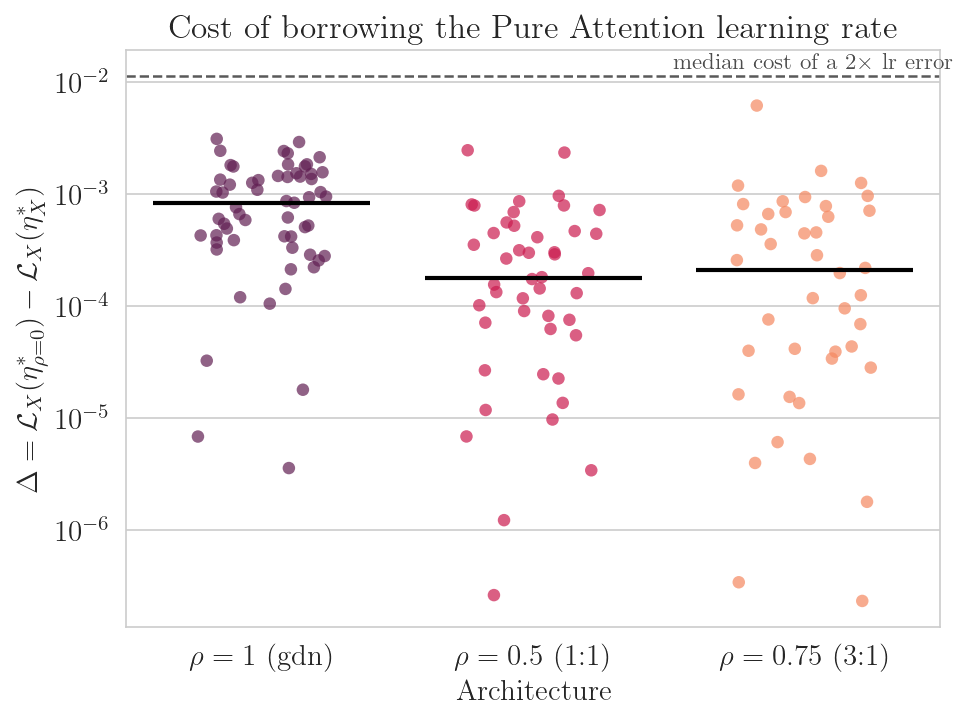

In [22]:
sns.set_palette(sns.color_palette("rocket"))

plot_transfer_penalty(transfer_table)
plt.show()
plt.close()

### What this plot shows

**Objective.** State the size of the transfer penalty against a scale that makes it
interpretable. A loss gap in nats has no meaning on its own, so the plot pairs every
measured penalty with the cost of a routine learning-rate error.

**What is plotted.**

- **x-axis**: architecture. $\rho$ is the fraction of Gated DeltaNet layers, so
  $\rho=1$ is Pure GDN and $\rho=0.5$ is the 1:1 GDN:ATTN hybrid.
- **y-axis**: the transfer penalty $\Delta$, log scale. One point is one cell
  $(N, D, \mathrm{GBS})$. For that cell, $\mathcal{L}_X$ is the quadratic fitted to
  architecture $X$'s validation loss against $\log_2 \eta$, and
  $\Delta = \mathcal{L}_X(\eta^*_{\rho=0}) - \mathcal{L}_X(\eta^*_X)$, where
  $\eta^*_{\rho=0}$ is the vertex of the Pure Attention fit for the *same* cell and
  $\eta^*_X$ is the vertex of $X$'s own fit. Both terms are read off one curve, so
  $\Delta \geq 0$ by construction and no additional runs are required.
- **Colour**: architecture, matching the x-axis. It carries no extra information; it
  keeps the three groups separable where the jitter overlaps.
- **Black bar**: the median $\Delta$ within each architecture.
- **Dashed line**: the reference scale, at 0.0113 nats. Per cell,
  `grid_step_cost` is $\tfrac{1}{2}[\mathcal{L}_X(2\eta^*_X) + \mathcal{L}_X(\eta^*_X/2)] - \mathcal{L}_X(\eta^*_X)$,
  the loss cost of landing one grid step ($2\times$) off $X$'s own optimum, averaged over
  the two directions to remove the asymmetry of the parabola. The line is the median of
  this quantity over all cells.

**How it meets the objective.** The claim "learning rates transfer" is only useful if the
transfer error is small relative to something a practitioner already tolerates. The sweep
grid is spaced by factors of two, so a $2\times$ error is the finest miss any sweep on this
grid can make: it is the resolution floor of the procedure being replaced. Every point
lying below the dashed line means reusing the Pure Attention learning rate costs less than
the sweep's own discretisation error, which is the operational statement that the sweep
can be skipped. Plotting every cell rather than a summary statistic exposes the worst
case, not just the typical one; the log y-axis keeps the small values readable and would
make any outlier approaching the band visible.

**Reading.** All 147 cells fall below the reference line. The largest single penalty is
0.0062 nats, still $1.8\times$ under the band, and the medians are $10$–$60\times$ under it.
Pure GDN transfers least well of the three, which is the expected ordering: it shares no
layers with the source architecture.


## Plot 2: agreement of the optima

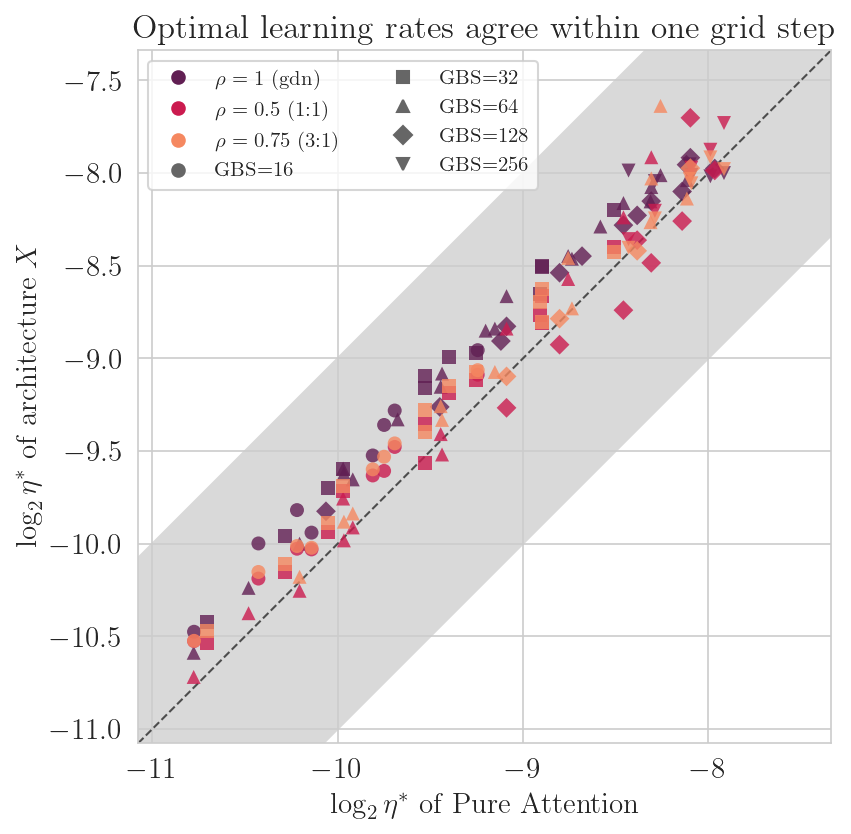

In [23]:
plot_optimum_agreement(transfer_table)
plt.show()
plt.close()

### What this plot shows

**Objective.** Show *why* the penalty in Plot 1 is small, and distinguish two cases that
Plot 1 cannot separate: optima that genuinely coincide, versus optima that differ but sit
in a region where the loss curve is flat. The two support different claims.

**What is plotted.**

- **x-axis**: $\log_2 \eta^*_{\rho=0}$, the Pure Attention optimum for a cell.
- **y-axis**: $\log_2 \eta^*_X$, architecture $X$'s own optimum for the *same* cell.
  Both are vertices of the fitted quadratics, so they are continuous values rather than
  grid points. Log2 is the natural axis because the sweep is geometric and the fit is
  quadratic in $\log_2 \eta$.
- **Colour**: architecture. **Marker shape**: global batch size.
- **Dashed diagonal**: perfect agreement, $\eta^*_X = \eta^*_{\rho=0}$.
- **Grey band**: $\pm 1$ in $\log_2$, that is, within one factor of two — one step of the
  sweep grid. A point inside the band names the same grid value the sweep would return.

**How it meets the objective.** Plot 1 compresses each cell to a scalar and so cannot tell
whether $\Delta$ is small because the optima agree or because the curve is flat near its
minimum. This plot reports the optima directly. Agreement along the diagonal establishes
that the underlying quantity transfers, not merely that the loss is insensitive.
Structure *off* the diagonal is equally informative: a cloud shifted parallel to the
diagonal is a constant multiplicative offset, which is correctable by a single scalar
learned once, whereas a rotation or fanning would mean the offset depends on $N$, $D$ or
GBS and no single correction exists. Encoding batch size in the marker lets the reader
check for the fanning case by eye, since GBS is the regressor most likely to drive a
dependence.

**Reading.** All 147 cells fall inside the $\pm 1$ band, with a maximum deviation of 0.62
in $\log_2$. The cloud sits slightly *above* the diagonal in 88% of cells: the non-attention
optimum is consistently a little higher than the Pure Attention optimum, with a median
offset of $0.29$ in $\log_2$ for Pure GDN and $0.12$–$0.13$ for the hybrids. This is a
systematic shift, not scatter, and it is parallel rather than fanned — no marker shape
separates from the rest. So the honest statement is that Pure Attention's learning rate
transfers directly at a cost below the grid resolution, and that a small constant upward
correction, larger for higher $\rho$, would centre the residual if one wanted it.


## Plot 3: transfer penalty against compute

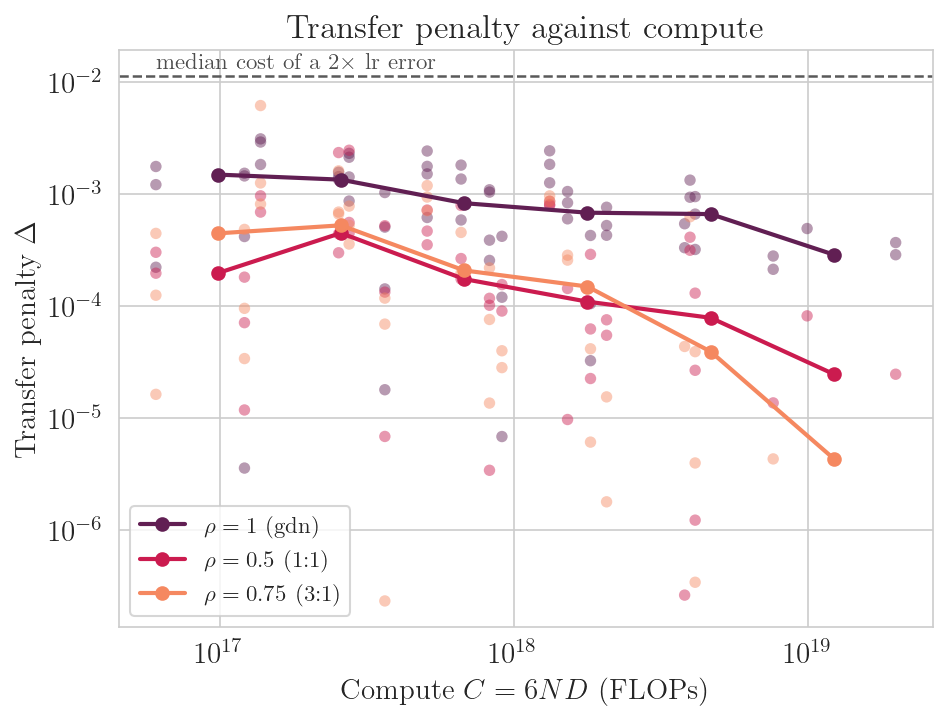

In [24]:
plot_transfer_vs_compute(transfer_table)
plt.show()
plt.close()

### What this plot shows

**Objective.** Test whether the result survives extrapolation. The experiments here are
small, and the value of the finding lies in applying it at scales that were not run, so
the relevant question is whether the penalty is stable, shrinking or growing along the
compute axis.

**What is plotted.**

- **x-axis**: compute $C = 6ND$ in FLOPs, log scale, using the standard estimate of
  forward-plus-backward cost for $N$ non-embedding parameters over $D$ tokens. Range here
  is $6\times10^{16}$ to $2\times10^{19}$.
- **y-axis**: the transfer penalty $\Delta$, log scale, defined as in Plot 1.
- **Faint points**: individual cells. **Solid lines with markers**: the median $\Delta$
  within each of six equal-width bins in $\log_{10} C$, one line per architecture. Cells
  are binned rather than joined directly because distinct $(N, D, \mathrm{GBS})$
  combinations land at nearby compute values, and joining them produces zig-zags that
  reflect the combinatorics of the grid rather than any trend. The median is used, not the
  mean, so that one bad cell in a sparse bin cannot swing the line.
- **Dashed line**: the same reference scale as Plot 1.

**How it meets the objective.** A reviewer's first objection to a transferability claim is
that it holds only at the small scales tested. Two things are needed to answer this: the
trend of the penalty with compute, and the margin to the reference scale along that trend.
Both are on the plot. A flat or falling trend means nothing in the data suggests the
result degrades with scale; a rising trend would require the claim to be scoped to the
range tested. Note what the plot can and cannot do: it shows no degradation across the
2.5 decades of compute covered here, which is evidence against a scale-dependent
breakdown, but it does not prove the result holds at arbitrary scale. That is a limit of
the data, not of the presentation.

**Reading.** All three architectures are flat to gently decreasing across the range, and
stay roughly an order of magnitude below the reference line throughout. The ordering seen
in Plot 1 persists at every compute scale: Pure GDN sits highest, the two hybrids lower
and close together.


## Plot 4: one cell, for intuition

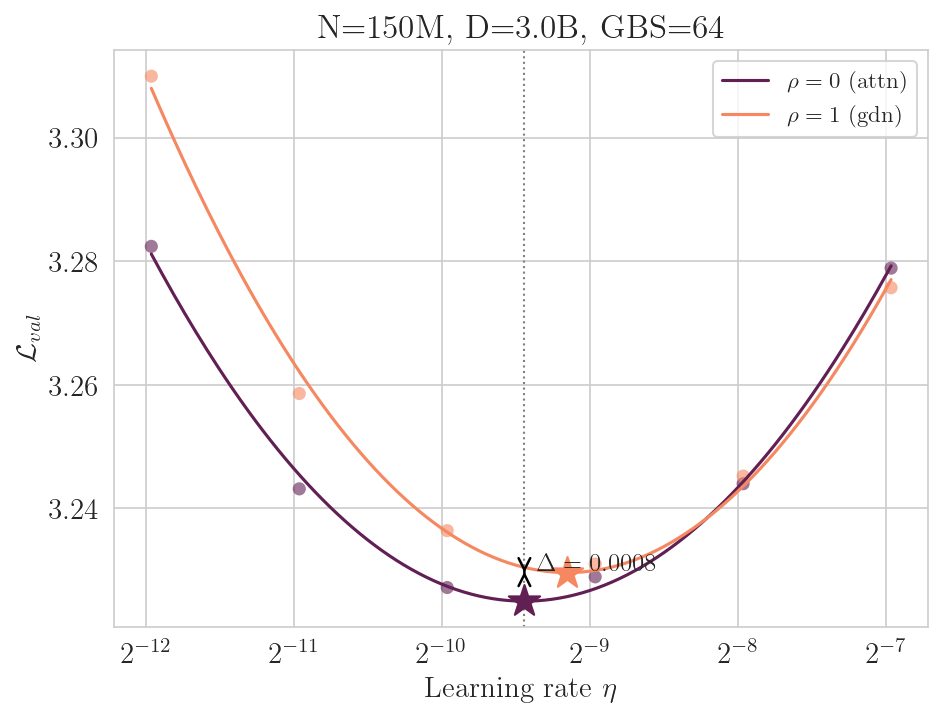

In [25]:
plot_transfer_example(
    transfer_collectors,
    n="150M",
    d="3.0B",
    gbs=64,
    arch_id="gdn",
    attn_lr_filter=in_transfer_lr_grid,
)
plt.show()
plt.close()

### What this plot shows

**Objective.** Make the quantity $\Delta$ concrete. Plots 1 to 3 are aggregate; this panel
shows the construction on a single cell so the reader can verify that the definition is
what they think it is. It is an illustration, not evidence.

**What is plotted.** One cell, $N=150$M, $D=3.0$B, $\mathrm{GBS}=64$, chosen as a mid-range
configuration with full learning-rate coverage.

- **x-axis**: learning rate $\eta$, log2 scale. **y-axis**: validation loss.
- **Points**: measured runs, one per swept learning rate, for Pure Attention and for
  Pure GDN.
- **Curves**: the quadratic fits in $\log_2 \eta$ that every number in this section is
  derived from. **Stars**: each curve's own vertex, $\eta^*_{\rho=0}$ and $\eta^*_X$.
- **Dotted vertical line**: $\eta^*_{\rho=0}$, the learning rate being transferred.
- **Arrow**: $\Delta$, the vertical distance on the GDN curve between its own minimum and
  its value at the Pure Attention optimum. This is one point from Plot 1, drawn in place.

**How it meets the objective.** The measurement rests on evaluating one architecture's
fitted curve at another architecture's optimum, which is easy to state and easy to
misread. Showing the fits, the data behind them, and the arrow itself lets a reader
confirm the arithmetic and judge the fit quality directly: whether the parabola tracks the
points, whether the vertex is interpolated rather than extrapolated off the swept range,
and whether the curvature near the minimum is strong enough for the vertex to be
well-determined. These are the assumptions the aggregate plots depend on and cannot
display.

**Caveat.** A single cell cannot support the general claim, and is not offered as doing so.
It also shows the favourable structural fact behind the whole result: near the minimum the
curve is shallow in $\log_2 \eta$, so a moderate error in the learning rate produces a
much smaller error in loss. Plot 1 is what establishes that this holds across all 147 cells
rather than at this one configuration.
